In [18]:
import numpy as np, uproot as ur, awkward as ak, pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import mplhep as hep
hep.style.use("CMS")

plt.rcParams['figure.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'
plt.rcParams['savefig.bbox']='tight'
plt.rcParams['legend.frameon']=True
plt.rcParams['legend.edgecolor']='white'
import uproot,glob#,ROOT

from scipy.optimize import curve_fit, minimize

plt.rcParams["figure.figsize"] = (10, 8)

import gc

In [2]:
m_lcp=2286.46/1000
m_D0bar=1864.84/1000

In [3]:
#filename="D0bar_lcp_sim_tuples_nopid_hadd.root"

filename="hadd_D0bar_tuples.root"
arrays_nopid=ur.open(filename+':events').arrays()
filename="nosupports.root"
arrays_nopid_nosupports=ur.open(filename+':events').arrays()

filename="hadd_D0bar_pi0_tuples.root"
arrays_nopid_pi0=ur.open(filename+':events').arrays()

filename="hadd_D0bar_gamma_tuples.root"
arrays_nopid_gamma=ur.open(filename+':events').arrays()

#filename="D0bar_lcp_sim_tuples_withpid_hadd.root"
#arrays_withpid=ur.open(filename+':events').arrays()

In [4]:
gauss_plus_poly=lambda x,A, mu,sigma, *c: A * np.exp(-(x-mu)**2/(2*sigma**2))/(abs(sigma)*np.sqrt(2*np.pi))+sum((c[i]*x**i for i in range(len(c))))

In [5]:
Ngen=100000

In [6]:
# y, x, _ = plt.hist(arrays['invmass'][arrays['topo']==0],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100),
#                   label='recon events')
# bc=(x[1:]+x[:-1])/2
# p0=(100, m_D0bar, 0.03, 0,0)
# fnc=gauss_plus_poly
# dy=np.sqrt(y)+(y==0)
# coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
# dx=x[1]-x[0]
# label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
# xx=np.linspace(x[0],x[-1],100)
# plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
# plt.xlabel("$m_{K^+\pi^-}$ [GeV]")
# plt.legend(fontsize=20)
# plt.show()

# y, x, _=plt.hist(arrays['invmass'][arrays['topo']==2],bins=np.linspace(m_lcp-.15,m_lcp+.15, 100),
#                 label='recon events')
# bc=(x[1:]+x[:-1])/2
# p0=(100, m_lcp, 0.03, 0,0)
# fnc=gauss_plus_poly
# dy=np.sqrt(y)+(y==0)
# coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
# dx=x[1]-x[0]
# label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
# xx=np.linspace(x[0],x[-1],100)
# plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
# plt.xlabel("$m_{K^-\pi^+p}$ [GeV]")
# plt.legend(fontsize=20)
# plt.show()

In [7]:
# y, x, _ = plt.hist(arrays['missmass'][arrays['topo']==0],bins=np.linspace(m_lcp-.15,m_lcp+.15, 100),
#                   label='recon events')
# bc=(x[1:]+x[:-1])/2
# p0=(100, m_lcp, 0.03, 0,0)
# fnc=gauss_plus_poly
# dy=np.sqrt(y)+(y==0)
# coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
# dx=x[1]-x[0]
# label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
# xx=np.linspace(x[0],x[-1],100)
# plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
# plt.xlabel("$m_{X}[\\gamma^*p\\rightarrow K^+\pi^-X]$ [GeV]")
# plt.legend(fontsize=20)
# plt.show()

# y, x, _=plt.hist(arrays['missmass'][arrays['topo']==2],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100),
#                 label='recon events')
# bc=(x[1:]+x[:-1])/2
# p0=(100, m_D0bar, 0.03, 0,0)
# fnc=gauss_plus_poly
# dy=np.sqrt(y)+(y==0)
# coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
# dx=x[1]-x[0]
# label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
# xx=np.linspace(x[0],x[-1],100)
# plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
# plt.xlabel("$m_{X}[\\gamma^*p\\rightarrow K^-\pi^+p X]$ [GeV]")
# plt.legend(fontsize=20)
# plt.show()

In [8]:
#print(len(arrays['invmass'][(arrays['topo']==0)&(arrays['invmass']>1.8)&(arrays['invmass']<1.9)])/96000)

In [9]:
# (((1 GeV) / c) / elementary charge) / (5 tesla) = 66.712819 cm
min_radius_of_curvature=35;
min_pT=min_radius_of_curvature/66.7
print(min_pT)

0.5247376311844077


0.11318
100000


/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_1551/798420146.py:68: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  coeff, var_matrix = curve_fit(fnc, np.array(bc), np.array(y), p0=p0,sigma=np.array(dy))


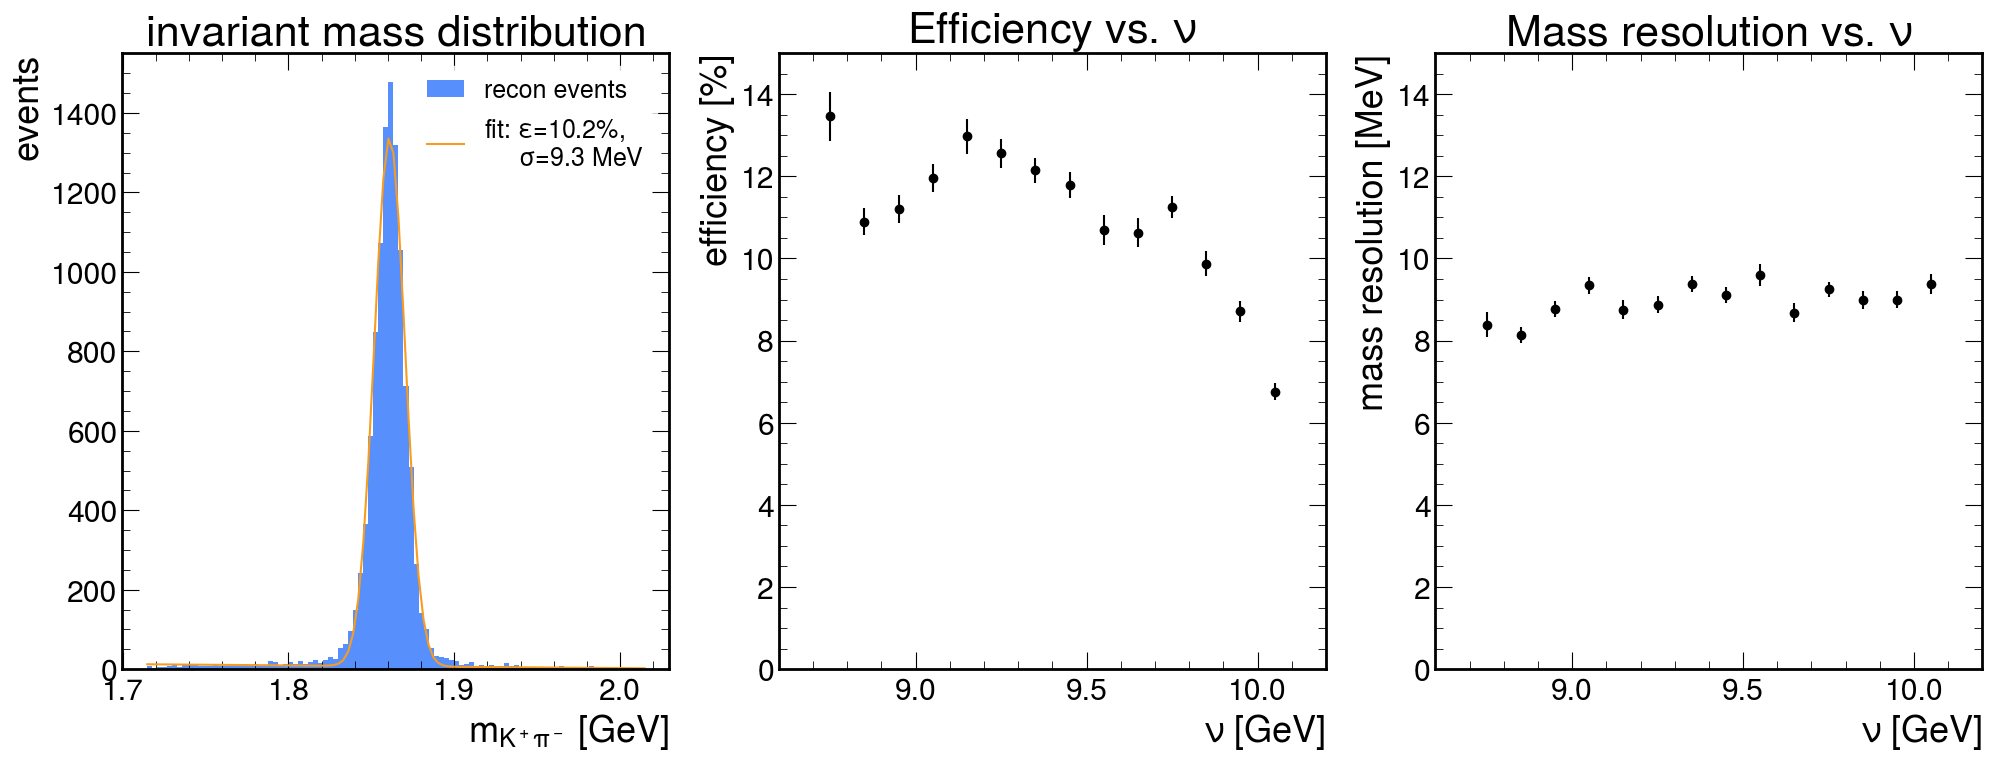

In [11]:
arrays=arrays_nopid
deg=np.pi/180
fig, axs=plt.subplots(1,3,figsize=(24,8))

selection=(arrays['topo']==0)&(arrays['mvtx_status']==63)
for p in "K pi".split():
    for i in range(3):
        selection=selection&(np.abs(np.arctan2(arrays[f'{p}_py'],arrays[f'{p}_px'])-np.arctan2(arrays[f'{p}_MVTX_y{i}'],arrays[f'{p}_MVTX_x{i}']))\
                     <3*np.pi/180/np.sin(np.arctan2(np.hypot(arrays[f'{p}_px'],arrays[f'{p}_py']),arrays[f'{p}_pz'])))
        #selection=selection&(np.abs(np.arctan2(np.hypot(arrays[f'{p}_px'],arrays[f'{p}_py']),arrays[f'{p}_pz']))-np.abs(np.arctan2(np.hypot(arrays[f'{p}_MVTX_x{i}'],arrays[f'{p}_MVTX_y{i}']),arrays[f'{p}_MVTX_z{i}']))
        #             <3*np.pi/180)
titles="CLAS12", "CLAS12 with MVTX acceptance"
plt.sca(axs[0])
y, x, _ = plt.hist(arrays['invmass'][selection],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100),
                      label='recon events')
print(sum(y)/100000)
bc=(x[1:]+x[:-1])/2
p0=(100, m_D0bar, 0.03, 0,0)
fnc=gauss_plus_poly
dy=np.sqrt(y)+(y==0)
coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
dx=x[1]-x[0]
label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
xx=np.linspace(x[0],x[-1],100)
plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
plt.xlabel("$m_{K^+\pi^-}$ [GeV]")
plt.ylabel("events")
plt.legend(fontsize=18)
plt.title("invariant mass distribution")


for j in range(1):
    #if j!=0:
    #    continue
    arrays=arrays_nopid if j==0 else arrays_nopid_gamma if j==1 else arrays_nopid_pi0
    
    selection=(arrays['topo']==0)&(arrays['mvtx_status']==63)
    for p in "K pi".split():
        for i in range(3):
            selection=selection&(np.abs(np.arctan2(arrays[f'{p}_py'],arrays[f'{p}_px'])-np.arctan2(arrays[f'{p}_MVTX_y{i}'],arrays[f'{p}_MVTX_x{i}']))\
                         <3*np.pi/180/np.sin(np.arctan2(np.hypot(arrays[f'{p}_px'],arrays[f'{p}_py']),arrays[f'{p}_pz'])))
            #selection=selection&(np.abs(np.arctan2(np.hypot(arrays[f'{p}_px'],arrays[f'{p}_py']),arrays[f'{p}_pz'])-np.arctan2(np.hypot(arrays[f'{p}_MVTX_x{i}'],arrays[f'{p}_MVTX_y{i}']),arrays[f'{p}_MVTX_z{i}']+50))
            #         <3*np.pi/180)
    plt.sca(axs[1])
    partitions=np.linspace(8.7,10.1,15)
    eff=[]
    deff=[]
    res=[]
    dres=[]
    nu=[]
    #pre-tabulated numbers of events per bin
    #events_per_nu_bin=[np.array([1498,4404,5569,6497,7207,7663,7833,8176,8320,8640,8760,8906,9048,7479]),
    #                  np.array([1498,4404,5569,6497,7207,7663,7833,8176,8320,8640,8760,8906,9048,7479]),
    #                  np.array([1498,4404,5569,6497,7207,7663,7833,8176,8320,8640,8760,8906,9048,7479])][j]

    events_per_nu_bin=[[np.int64(1199), np.int64(4050), np.int64(4942), np.int64(5962), np.int64(6447), np.int64(7101), np.int64(7452), np.int64(7257), np.int64(7846), np.int64(7781), np.int64(8140), np.int64(8022), np.int64(8461), np.int64(8351), np.int64(6989)],
        [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(4533), np.int64(9593), np.int64(12094), np.int64(13810), np.int64(15344), np.int64(16032), np.int64(16731), np.int64(11863)],
        [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(4672), np.int64(9597), np.int64(11926), np.int64(13631), np.int64(15285), np.int64(16047), np.int64(16953), np.int64(11889)]][j]
    print(sum(events_per_nu_bin))
    for i,(numin,numax) in enumerate(zip(partitions[:-1],partitions[1:])):
        y, x = np.histogram(arrays['invmass'][selection&(arrays['nu']>numin)&(arrays['nu']<numax)],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100))
        #print(y,x)
        dx=x[1]-x[0]
        bc=(x[1:]+x[:-1])/2
        p0=(100, m_D0bar, 0.03, 0,0)
        fnc=gauss_plus_poly
        dy=np.sqrt(y)+(y==0)
        coeff, var_matrix = curve_fit(fnc, np.array(bc), np.array(y), p0=p0,sigma=np.array(dy))
        eff.append(100*coeff[0]/events_per_nu_bin[i]/dx)
        deff.append(100*var_matrix[0][0]**.5/events_per_nu_bin[i]/dx)
    
        res.append(1000*coeff[2])
        dres.append(1000*var_matrix[2][2]**.5)
        
        nu.append((numin+numax)/2)
    
    plt.title("Efficiency vs. $\\nu$")
    plt.errorbar(nu, eff,deff, ls='', marker='o', color='krb'[j])
    plt.xlabel("$\\nu$ [GeV]")
    plt.ylabel("efficiency [%]")
    plt.ylim(0,15)
    plt.xlim(8.6,10.2)
    
    plt.sca(axs[2])
    plt.title("Mass resolution vs. $\\nu$")
    plt.errorbar(nu, res,dres, ls='', marker='o', color='krb'[j])
    plt.xlabel("$\\nu$ [GeV]")
    plt.ylabel("mass resolution [MeV]")
    plt.ylim(0,15)
    plt.xlim(8.6,10.2)



plt.savefig("images/mass_distibution_MC.pdf")
plt.show()

100000
0.10945
0.10955
0.11385
0.1163
0.11675


/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_1551/1986351636.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  coeff, var_matrix = curve_fit(fnc, np.array(bc), np.array(y), p0=p0,sigma=np.array(dy))


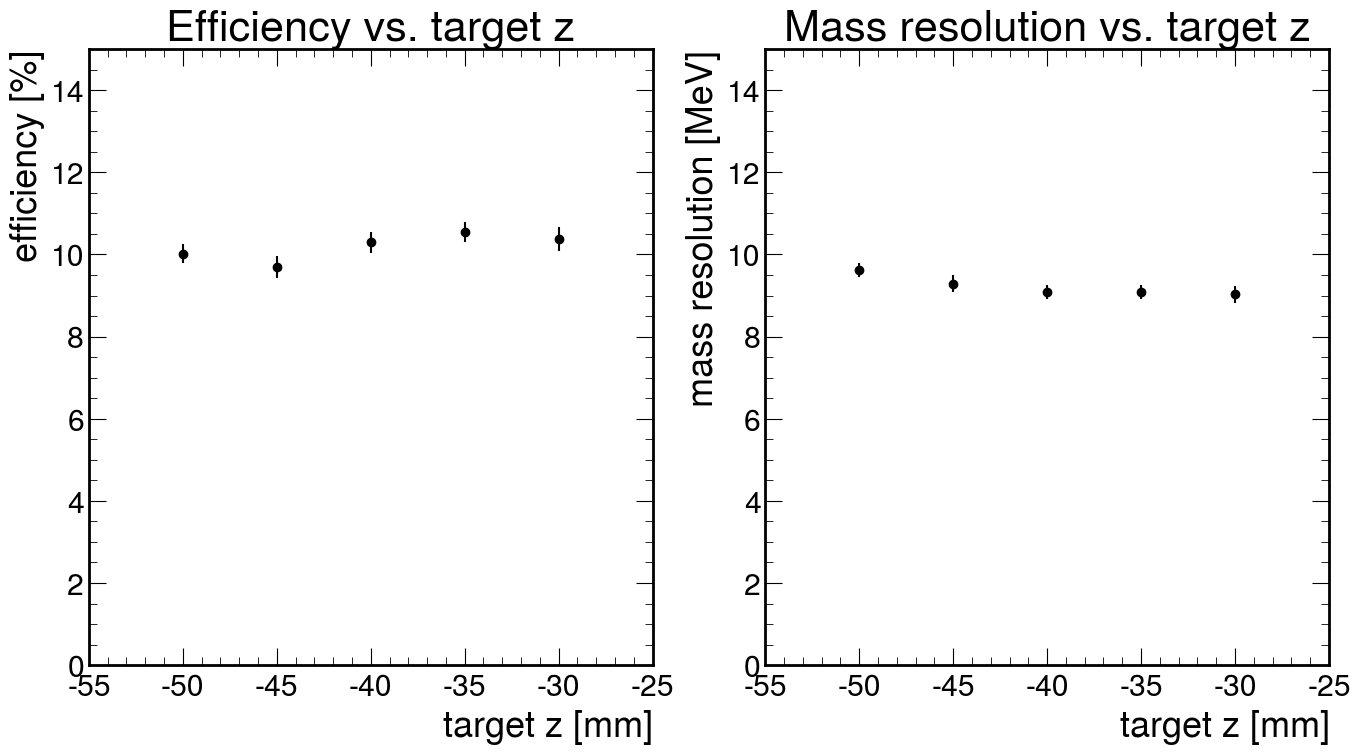

In [12]:
partitions=np.linspace(-52.5, -27.5, 6)/10

selection=(arrays['topo']==0)&(arrays['mvtx_status']==63)
for p in "K pi".split():
    for i in range(3):
        selection=selection&(np.abs(np.arctan2(arrays[f'{p}_py'],arrays[f'{p}_px'])-np.arctan2(arrays[f'{p}_MVTX_y{i}'],arrays[f'{p}_MVTX_x{i}']))\
                     <3*np.pi/180/np.sin(np.arctan2(np.hypot(arrays[f'{p}_px'],arrays[f'{p}_py']),arrays[f'{p}_pz'])))

fig, axs=plt.subplots(1,2,figsize=(16,8))
eff=[]
deff=[]
res=[]
dres=[]
z=[]
events_per_foil=np.array([1e5/5]*5)
print(sum(events_per_nu_bin))
for i,(zmin,zmax) in enumerate(zip(partitions[:-1],partitions[1:])):
    y, x = np.histogram(arrays['invmass'][selection&(arrays['foil_z_mc']>zmin)&(arrays['foil_z_mc']<zmax)],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100))
    print(sum(y)/20000)
    dx=x[1]-x[0]
    bc=(x[1:]+x[:-1])/2
    p0=(100, m_D0bar, 0.01, 0,0)
    fnc=gauss_plus_poly
    dy=np.sqrt(y)+(y==0)
    coeff, var_matrix = curve_fit(fnc, np.array(bc), np.array(y), p0=p0,sigma=np.array(dy))
    eff.append(100*coeff[0]/events_per_foil[i]/dx)
    deff.append(100*var_matrix[0][0]**.5/events_per_foil[i]/dx)

    res.append(1000*coeff[2])
    dres.append(1000*var_matrix[2][2]**.5)
    
    z.append((zmin+zmax)/2*10)

plt.sca(axs[0])
plt.title("Efficiency vs. target z")
plt.errorbar(z, eff,deff, ls='', marker='o', color='k')
plt.xlabel("target $z$ [mm]")
plt.ylabel("efficiency [%]")
plt.ylim(0, 15)
plt.xlim(-55,-25)

plt.sca(axs[1])
plt.title("Mass resolution vs. target z")
plt.errorbar(z, res,dres, ls='', marker='o', color='k')
plt.xlabel("target $z$ [mm]")
plt.ylabel("mass resolution [MeV]")
plt.ylim(0, 15)
plt.xlim(-55,-25)



plt.savefig("images/mass_distibution_MC_foils.pdf")

0.03215001999999751


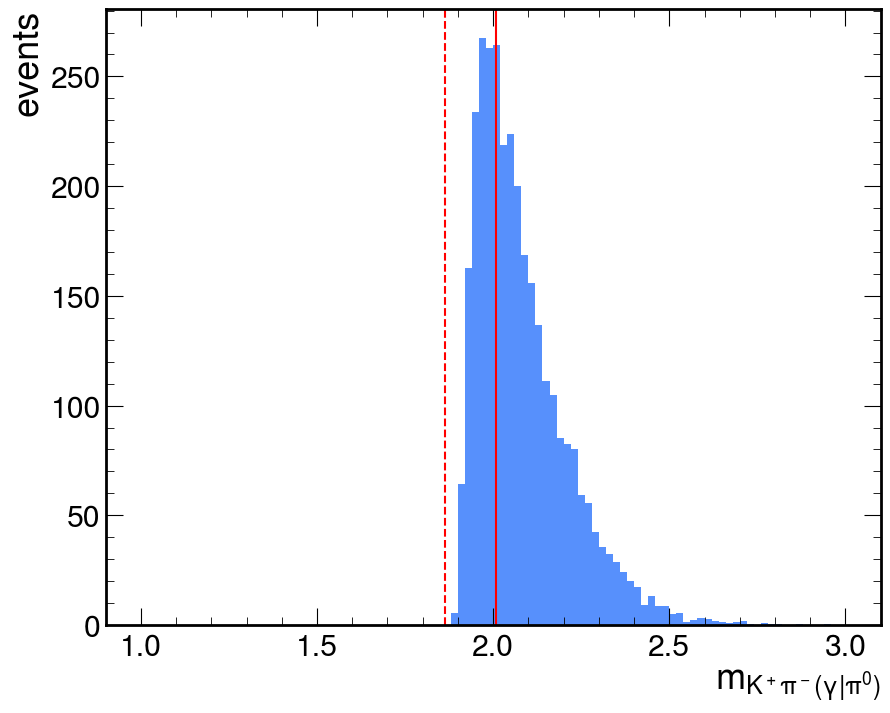

In [418]:
arrays_nopid_pi0['BR']=np.repeat(.647,len(arrays_nopid_pi0))
arrays_nopid_gamma['BR']=np.repeat(.353,len(arrays_nopid_gamma))

df=ak.concatenate([arrays_nopid_gamma,arrays_nopid_pi0])
a=df.invmass_star
selection=(df.invmass>1.83)&(df.invmass<2.0)&(df.ph_E>.2)&(df.n_ph>=1)&(df.n_ph<=2)

print(sum(df.BR[selection])/100000)
plt.hist(a[selection], bins=100, range=(1.0, 3.0), weights=df.BR[selection])
plt.xlabel("$m_{K^+\\pi^-(\\gamma|\\pi^0)}$")
plt.ylabel("events")
plt.axvline(2.00686, color='r')
plt.axvline(1.864, color='r', ls='--')
plt.show()


# now for the vertex resolutions

In [15]:
# adapted from
# https://www.geeksforgeeks.org/dsa/equation-of-circle-when-three-points-on-the-circle-are-given/
# Python3 implementation of the approach 
#from math import sqrt


# Function to find the circle on 
# which the given three points lie 
def findHelix(x1, y1,z1, x2, y2,z2, x3, y3,z3, ROC_assist=None) :
    x12 = x1 - x2; 
    x13 = x1 - x3; 

    y12 = y1 - y2; 
    y13 = y1 - y3; 

    y31 = y3 - y1; 
    y21 = y2 - y1; 

    x31 = x3 - x1; 
    x21 = x2 - x1; 

    # x1^2 - x3^2 
    sx13 = np.pow(x1, 2) - np.pow(x3, 2); 

    # y1^2 - y3^2 
    sy13 = np.pow(y1, 2) - np.pow(y3, 2); 

    sx21 = np.pow(x2, 2) - np.pow(x1, 2); 
    sy21 = np.pow(y2, 2) - np.pow(y1, 2); 

    f = (((sx13) * (x12) + (sy13) * 
          (x12) + (sx21) * (x13) + 
          (sy21) * (x13)) / (2 * 
          ((y31) * (x12) - (y21) * (x13))));
            
    g = (((sx13) * (y12) + (sy13) * (y12) + 
          (sx21) * (y13) + (sy21) * (y13)) / 
          (2 * ((x31) * (y12) - (x21) * (y13)))); 

    c = (-np.pow(x1, 2) - np.pow(y1, 2) - 
         2 * g * x1 - 2 * f * y1); 

    # eqn of circle be x^2 + y^2 + 2*g*x + 2*f*y + c = 0 
    # where centre is (h = -g, k = -f) and 
    # radius r as r^2 = h^2 + k^2 - c 
    h = -g; 
    k = -f; 
    sqr_of_r = h * h + k * k - c; 

    # r is the radius 
    r = np.sqrt(sqr_of_r)

    if ROC_assist is not None:
        rprev=r
        r=ROC_assist
        # anchor a weighted mean of the three hits,
        # and move the center accordingly
        w1,w2,w3=1,1,0.5
        x0=(x1*w1+x2*w2+x3*w3)/(w1+w2+w3)
        h=x0+(h-x0)*r/rprev
        
        y0=(y1*w1+y2*w2+y3*w3)/(w1+w2+w3)
        k=y0+(k-y0)*r/rprev
    

    #now add the longitudinal parameters
    psi1,psi2,psi3=np.arctan2(y1-k,x1-h),np.arctan2(y2-k,x2-h),np.arctan2(y3-k,x3-h)
    #limit these to be less than pi from the first point
    psi2=psi2+(psi2>np.pi+psi1)*-2*np.pi-(psi2<-np.pi+psi1)*2*np.pi
    psi3=psi3+(psi3>np.pi+psi1)*-2*np.pi-(psi3<-np.pi+psi1)*2*np.pi

    #weight the outermost layer less than the other two
    w1,w2,w3=1,1,0.5
    
    sumpsi=psi1*w1+psi2*w2+psi3*w3
    sumpsi2=psi1**2*w1+psi2**2*w2+psi3**2*w3
    N=w1+w2+w3
    sumpsiz=psi1*z1*w1+psi2*z2*w2+psi3*z3*w3
    sumz=z1*w1+z2*w2+z3*w3;

    det=sumpsi**2-N*sumpsi2


    t=(sumpsi*sumz-N*sumpsiz)/det
    z0=(-sumpsi2*sumz+sumpsi*sumpsiz)/det

    return h,k,r, t,z0

In [16]:
def circle_intersection_points(x1, y1, r1, x2, y2, r2):
    """
    Calculates the intersection points of two circles.

    Args:
        x1, y1, r1: Center coordinates and radius of the first circle.
        x2, y2, r2: Center coordinates and radius of the second circle.

    Returns:
        None if there are no intersections or infinite intersections (coincident circles).
        A single tuple (x, y) if the circles are tangent.
        A list of two tuples [(x1, y1), (x2, y2)] if there are two intersection points.
    """
    # Distance between centers
    d = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    # Calculate intersection points using the law of cosines and rotation/translation
    a = (r1**2 - r2**2 + d**2) / (2 * d)
    h = np.sqrt(r1**2 - a**2)
    
    # Coordinates of the point P2, which lies on the line connecting the centers
    x0 = x1 + a * (x2 - x1) / d
    y0 = y1 + a * (y2 - y1) / d

    # Intersection points
    intersection1_x = x0 + h * (y2 - y1) / d
    intersection1_y = y0 - h * (x2 - x1) / d
    intersection2_x = x0 - h * (y2 - y1) / d
    intersection2_y = y0 + h * (x2 - x1) / d

    order=np.hypot(intersection1_x,intersection1_y)<np.hypot(intersection2_x,intersection2_y)
    
    point1 = (intersection1_x*order+intersection2_x*(1-order), intersection1_y*order+intersection2_y*(1-order))
    point2 = (intersection2_x*order+intersection1_x*(1-order), intersection2_y*order+intersection1_y*(1-order))
    
    return [point1, point2]

nan nan


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


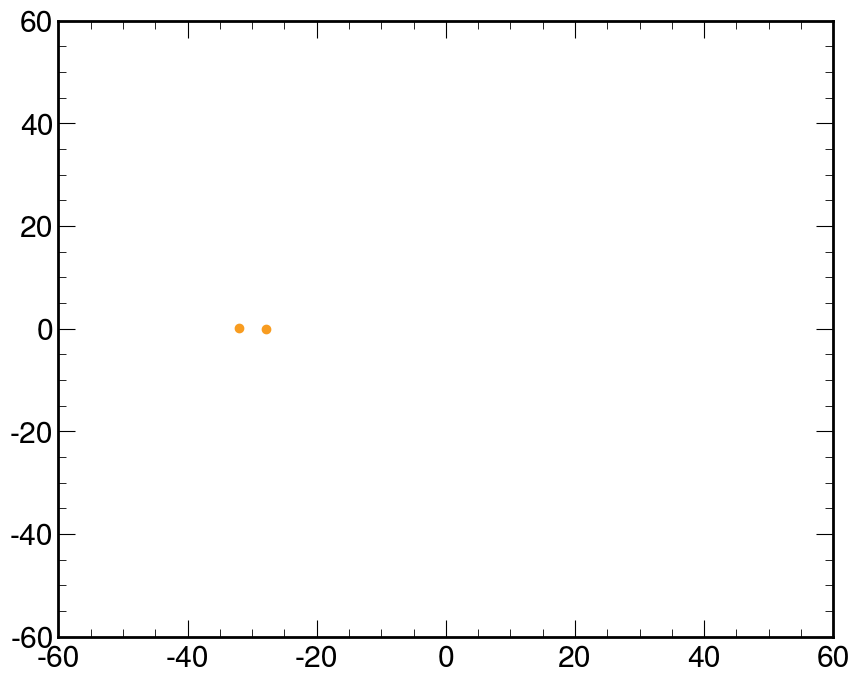

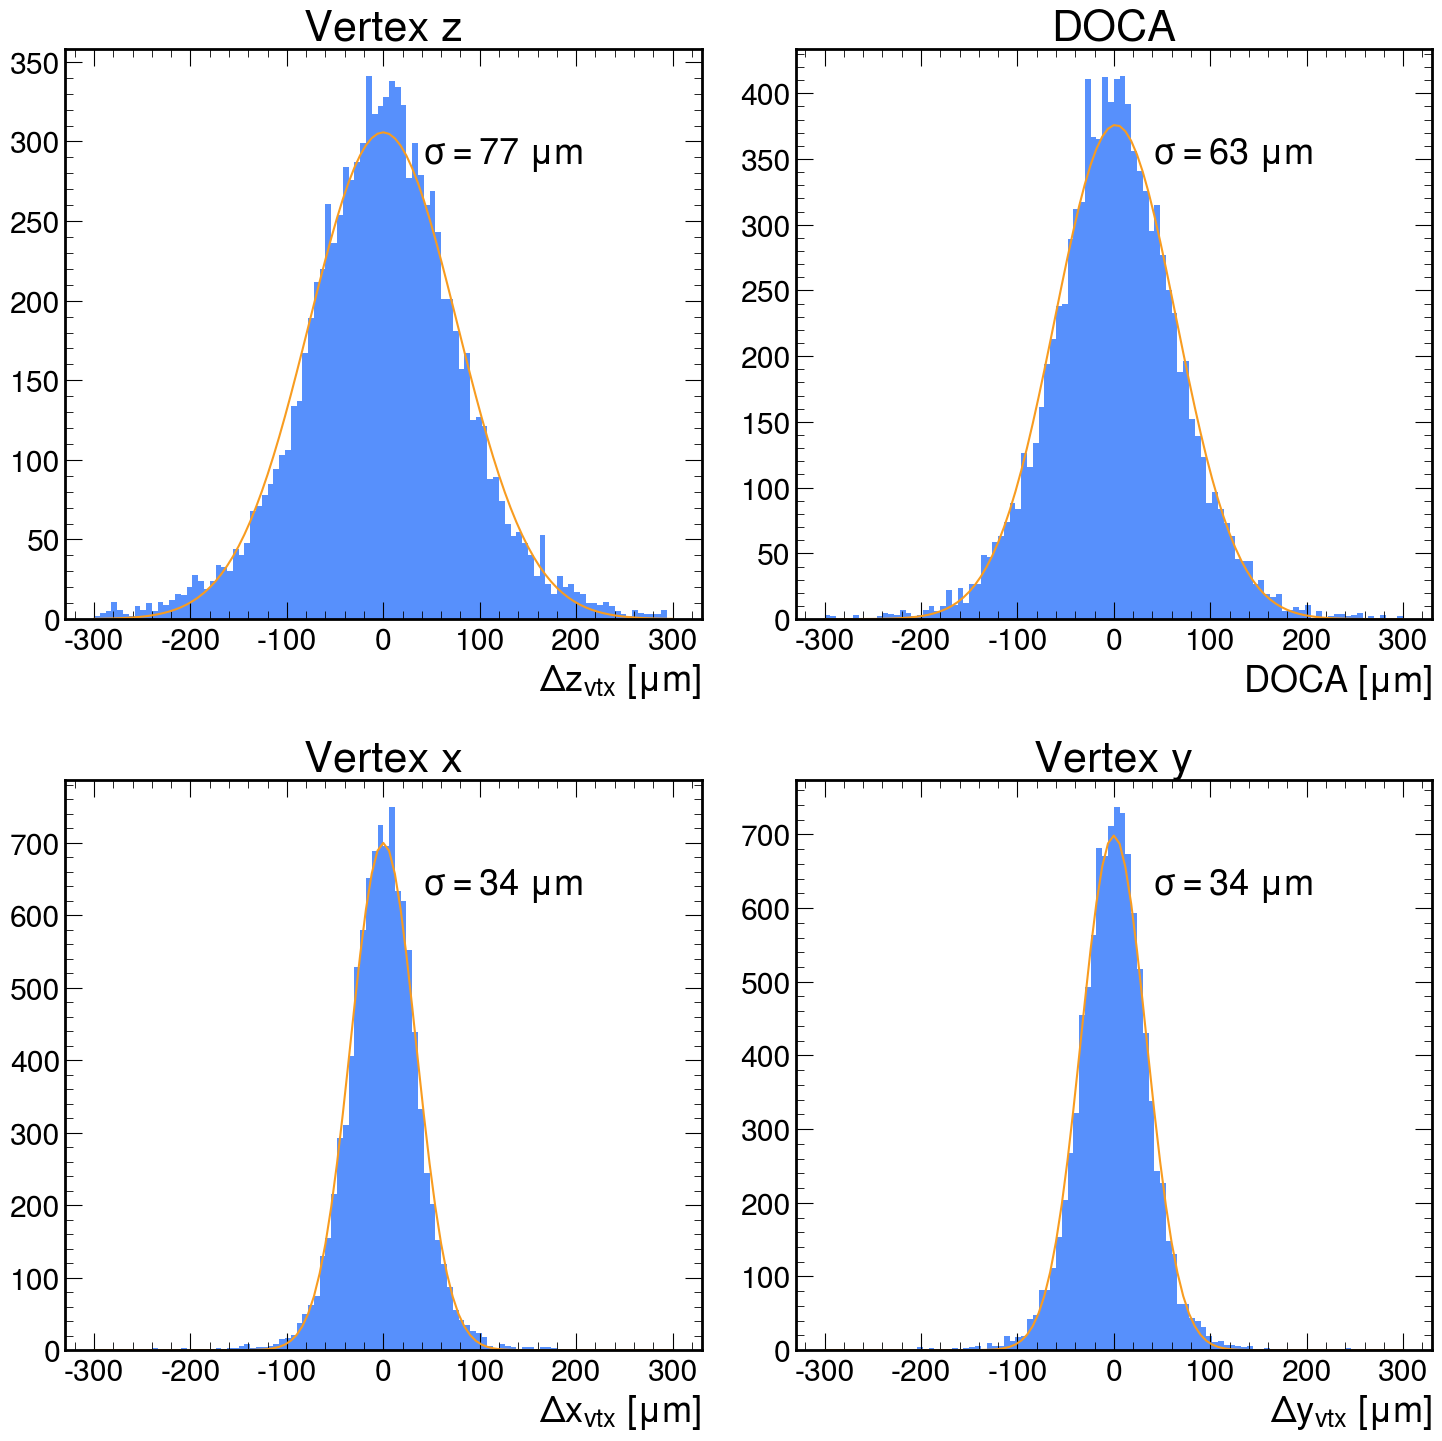

In [541]:

for df in arrays_nopid,:# arrays_nopid_pi0, arrays_nopid_gamma:
    df=ak.to_dataframe(df).copy()
    #first smear, since the resolution effects are not yet present in the simulation
    for p in 'K pi'.split():
        for i in range(3):
            smear=0.005
            for x in 'xyz':
                df[f'{p}_MVTX_{x}{i}_smear']=df[f'{p}_MVTX_{x}{i}']+np.random.normal(0,smear,len(df))


    #determine radius of curvature from the DC pt:

    for p in 'K pi'.split():
        df[f'{p}_ROC']=np.hypot(df[f'{p}_px'],df[f'{p}_py'])/(.299792458*5.0)*1000
    
    Kp_xc_recon,Kp_yc_recon,Kp_ROC_recon,Kp_t_recon,Kp_z0_recon=findHelix(*(df['K_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), 
                                                                     df['K_ROC'])
    pim_xc_recon,pim_yc_recon,pim_ROC_recon,pim_t_recon,pim_z0_recon=findHelix(*(df['pi_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), 
                                                                           df['pi_ROC'])
    _,_,df['pim_ROC_noassist'],_,_= findHelix(*(df['pi_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), None)
    _,_,df['Kp_ROC_noassist'],_,_= findHelix(*(df['K_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), None)

    #first determine where they intersect in the projected circles.  Then refine the estimate
    intersections=circle_intersection_points(Kp_xc_recon,Kp_yc_recon,Kp_ROC_recon, pim_xc_recon,pim_yc_recon,pim_ROC_recon)

    #now refine the position estimate
    psi1=np.atan2(intersections[0][1]-Kp_yc_recon,intersections[0][0]-Kp_xc_recon)
    df['Kp_MVTX_xref'],df['Kp_MVTX_yref'],df['Kp_MVTX_zref']=*intersections[0],Kp_z0_recon+Kp_t_recon*psi1
    
    
    denom = np.sqrt(1+(Kp_t_recon/Kp_ROC_recon)**2)
    df['Kp_MVTX_ux'],df['Kp_MVTX_uy'],df['Kp_MVTX_uz']=-np.sin(psi1)/denom, np.cos(psi1)/denom, Kp_t_recon/Kp_ROC_recon/denom
    
    
    psi2=np.atan2(intersections[0][1]-pim_yc_recon,intersections[0][0]-pim_xc_recon)
    df['pim_MVTX_xref'],df['pim_MVTX_yref'],df['pim_MVTX_zref']=*intersections[0], pim_z0_recon+pim_t_recon*psi2
    
    
    denom = np.sqrt(1+(pim_t_recon/pim_ROC_recon)**2)
    df['pim_MVTX_ux'],df['pim_MVTX_uy'],df['pim_MVTX_uz']=-np.sin(psi2)/denom, np.cos(psi2)/denom, pim_t_recon/pim_ROC_recon/denom
    
    df['dot']=df.eval(f'Kp_MVTX_ux*pim_MVTX_ux+Kp_MVTX_uy*pim_MVTX_uy+Kp_MVTX_uz*pim_MVTX_uz')
    #cross product of the unit vectors
    df['cross_x'], df['cross_y'], df['cross_z']=(df.eval(f'Kp_MVTX_u{x}*pim_MVTX_u{y}-Kp_MVTX_u{y}*pim_MVTX_u{x}') for (x,y) in ("yz","zx","xy"))
    
    
    df['doca']=df.eval('((Kp_MVTX_xref-pim_MVTX_xref)*cross_x+(Kp_MVTX_yref-pim_MVTX_yref)*cross_y+(Kp_MVTX_zref-pim_MVTX_zref)*cross_z)/'+\
                      'sqrt(cross_x**2+cross_y**2+cross_z**2)')
    
    #r=x1​−x2​,b=u1​⋅u2​,d=u1​⋅r,e=u2​⋅r,Δ=1−b2
    b=df.eval("dot")
    d=df.eval('(Kp_MVTX_xref-pim_MVTX_xref)*Kp_MVTX_ux+(Kp_MVTX_yref-pim_MVTX_yref)*Kp_MVTX_uy+(Kp_MVTX_zref-pim_MVTX_zref)*Kp_MVTX_uz')
    e=df.eval('(Kp_MVTX_xref-pim_MVTX_xref)*pim_MVTX_ux+(Kp_MVTX_yref-pim_MVTX_yref)*pim_MVTX_uy+(Kp_MVTX_zref-pim_MVTX_zref)*pim_MVTX_uz')
    df['vtx_x'], df['vtx_y'], df['vtx_z']=(df.eval(f'(Kp_MVTX_{x}ref+pim_MVTX_{x}ref)/2')+\
                                                    +(df.eval(f'Kp_MVTX_u{x}')*(b*e-d)+df.eval(f'pim_MVTX_u{x}')*(e-b*d))/(2*(1-b**2)) for x in "xyz")

    

    i=4
    for p in 'K pi'.split():
        #plot the hits
        plt.plot(*[[df[f'{p}_MVTX_{a}{j}'][i] for j in (0,1,2)] for a in 'xy'], ls ='', marker='o')
        ph=np.linspace(-np.pi, np.pi, 180)
    plt.plot(Kp_xc_recon[i]+np.cos(ph)*Kp_ROC_recon[i],Kp_yc_recon[i]+np.sin(ph)*Kp_ROC_recon[i])
    plt.plot(pim_xc_recon[i]+np.cos(ph)*pim_ROC_recon[i],pim_yc_recon[i]+np.sin(ph)*pim_ROC_recon[i])
    print(intersections[0][0][i],intersections[0][1][i])
    plt.plot(intersections[0][0][i],intersections[0][1][i], marker='x')
        
    plt.xlim(-60,60)
    plt.ylim(-60,60)
    plt.show()

    
    #selection=(df.mvtx_status==63)&(df.pi_th>8.9*np.pi/180)&(df.K_th>8.9*np.pi/180)&(df.invmass>1.83)&(df.invmass<1.9)
    fields="vtx_z-vtx_z_mc*10 doca vtx_x-vtx_x_mc*10 vtx_y-vtx_y_mc*10".split()
    labels="$\\Delta z_{\\rm vtx}$;DOCA;$\\Delta x_{\\rm vtx}$;$\\Delta y_{\\rm vtx}$".split(';')
    titles="Vertex z;DOCA;Vertex x;Vertex y".split(";")
    fig, axs=plt.subplots(2,2, figsize=(15,15))
    for i in range(4):
        plt.sca(axs[i//2][i%2])
        q='pi_th>8.9*3.14159/180 and K_th>8.9*3.14159/180 and mvtx_status==63 and invmass>1.83 and invmass<1.9 and pi_p>0.5 and K_p>0.5'
        #q+=" and (vtx_z+100)%5>0.1"
        q+=" and pim_ROC_noassist >300 and Kp_ROC_noassist>300"
        a=df.query(q).eval(fields[i])*1000
        y,x,_=plt.hist(a, bins=100, range=(-300,300))
        bc=(x[1:]+x[:-1])/2
        gauss= lambda x,A,mu,sigma : A*np.exp(-(x-mu)**2/(2*sigma**2))
        P,cov=curve_fit(gauss, bc,y,(1000,0,20),sigma=np.sqrt(y)+1*(y==0))
        sigma=P[2]
        plt.text(40, plt.gca().get_ylim()[1]*.8, f"$\\sigma={sigma:.0f}$ $\mu$m")
        plt.plot(x,gauss(x,*P))
        plt.xlabel(labels[i]+" [$\\mu$m]")
        plt.title(titles[i])
        #plt.legend()
    plt.tight_layout()
    plt.savefig("mvtx_resolutions.pdf")
    
    #print(np.std(dz[(abs(dz)<500)&(~np.isnan(dz))&selection]))
    plt.show()
    #plt.hist((df.doca)*1000, bins=100, range=(-1000, 1000))
    #plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


-0.744824334144738 0.24482879223143073


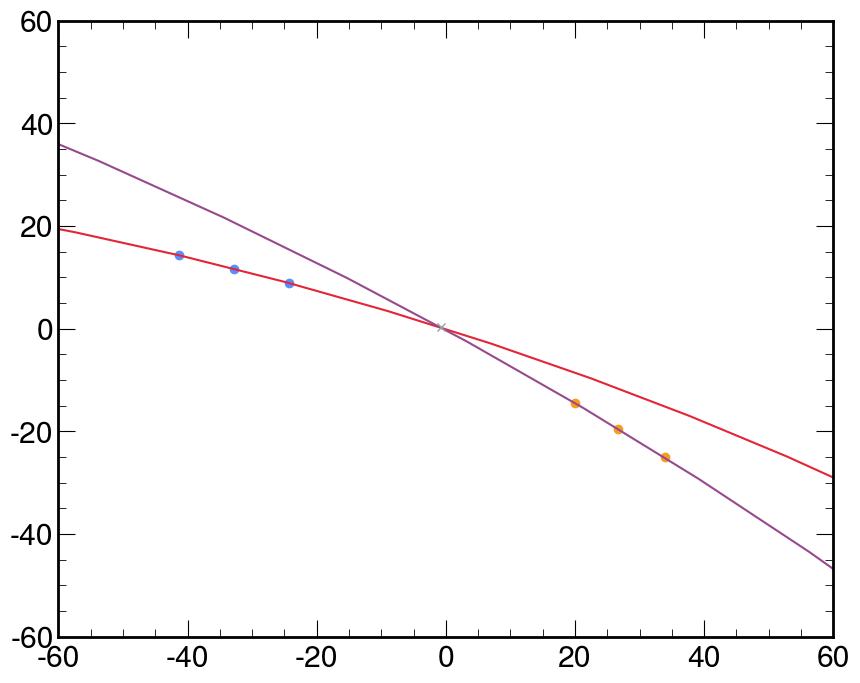

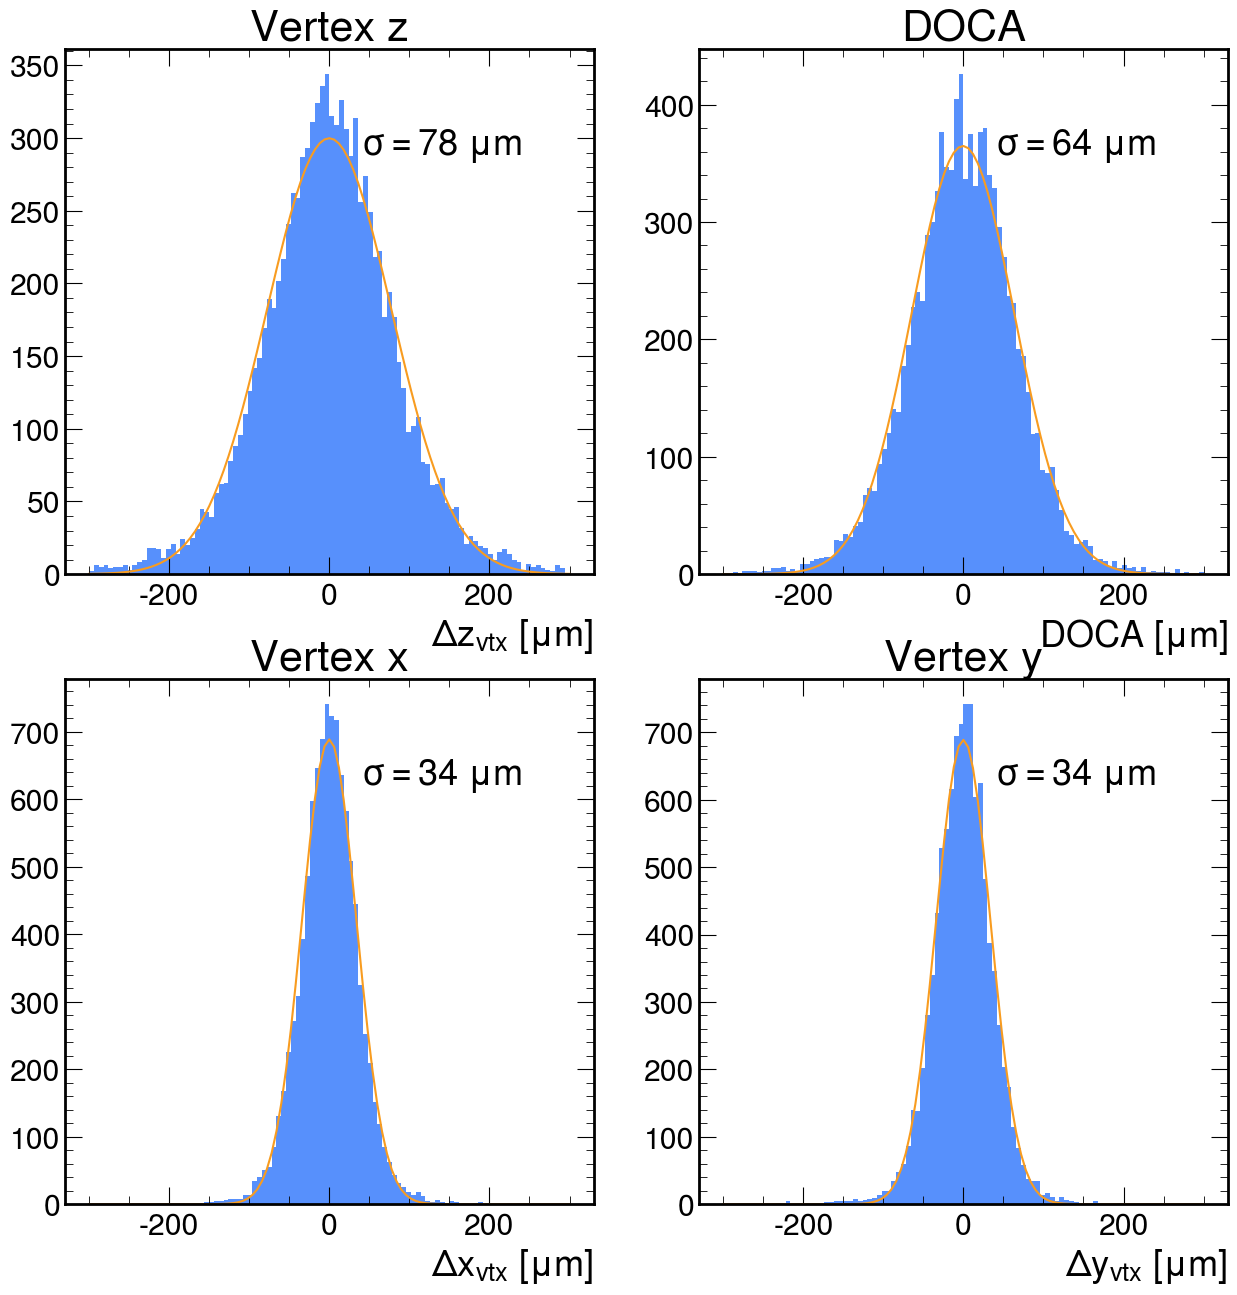

In [40]:

for df in arrays_nopid,:# arrays_nopid_pi0, arrays_nopid_gamma:
    df=ak.to_dataframe(df).copy()
    #first smear, since the resolution effects are not yet present in the simulation
    for p in 'K pi'.split():
        for i in range(3):
            smear=0.005
            for x in 'xyz':
                df[f'{p}_MVTX_{x}{i}_smear']=df[f'{p}_MVTX_{x}{i}']+np.random.normal(0,smear,len(df))


    #determine radius of curvature from the DC pt:
    for p in 'K pi'.split():
        df[f'{p}_ROC']=np.hypot(df[f'{p}_px'],df[f'{p}_py'])/(.299792458*5.0)*1000
    
    Kp_xc_recon,Kp_yc_recon,Kp_ROC_recon,Kp_t_recon,Kp_z0_recon=findHelix(*(df['K_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), 
                                                                     df['K_ROC'])
    pim_xc_recon,pim_yc_recon,pim_ROC_recon,pim_t_recon,pim_z0_recon=findHelix(*(df['pi_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), 
                                                                           df['pi_ROC'])
    _,_,df['pim_ROC_noassist'],_,_= findHelix(*(df['pi_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), None)
    _,_,df['Kp_ROC_noassist'],_,_= findHelix(*(df['K_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), None)

    #first determine where they intersect in the projected circles.  Then refine the estimate
    intersections=circle_intersection_points(Kp_xc_recon,Kp_yc_recon,Kp_ROC_recon, pim_xc_recon,pim_yc_recon,pim_ROC_recon)

    #now refine the position estimate
    psi1=np.atan2(intersections[0][1]-Kp_yc_recon,intersections[0][0]-Kp_xc_recon)
    psi2=np.atan2(intersections[0][1]-pim_yc_recon,intersections[0][0]-pim_xc_recon)


    #function that needs to be minimized to get the two points on the helices closest to one another
    def fnc(psis, xc1, yc1, r1, t1, z01, xc2, yc2, r2, t2, z02): 
        psi1, psi2 = psis 
        term_x = (xc1 + r1 * np.cos(psi1) - xc2 - r2 * np.cos(psi2))**2
        term_y = (yc1 + r1 * np.sin(psi1) - yc2 - r2 * np.sin(psi2))**2 
        term_z = (z01 + t1 * psi1 - z02 - t2 * psi2)**2
        return term_x + term_y + term_z
    
    # Run optimization sequentially for every event in your 1D arrays
    results = []
    for i in range(len(psi1)):
        # Grab the constants for ONLY event 'i'
        event_args = (
            Kp_xc_recon[i], Kp_yc_recon[i], Kp_ROC_recon[i], Kp_t_recon[i], Kp_z0_recon[i],
            pim_xc_recon[i], pim_yc_recon[i], pim_ROC_recon[i], pim_t_recon[i], pim_z0_recon[i]
        )
        #print(fnc((psi1[i],psi2[i]), *event_args))
        res = minimize(fun=fnc, x0=(psi1[i], psi2[i]), args=event_args, bounds=((psi1[i]-.3, psi1[i]+.3),(psi2[i]-.3,psi2[i]+.3)))
        #print(res)
        results.append(res.x) # Saves [opt_psi1, opt_psi2] for this loop
        #print((psi1[i]-res.x[0]),(psi2[i]-res.x[1]))
        #if i==10: break
    # Convert results into two clean 1D arrays
    results = np.array(results)
    psi1 = results[:, 0]
    psi2 = results[:, 1]
    


    
    df['vtx_x'], df['vtx_y'], df['vtx_z']=[(Kp_xc_recon+Kp_ROC_recon*np.cos(psi1)+pim_xc_recon+pim_ROC_recon*np.cos(psi2))/2,
                                            (Kp_yc_recon+Kp_ROC_recon*np.sin(psi1)+pim_yc_recon+pim_ROC_recon*np.sin(psi2))/2,
                                            (Kp_z0_recon+Kp_t_recon*psi1+pim_z0_recon+pim_t_recon*psi2)/2]
    df['doca']=np.sqrt((Kp_xc_recon+Kp_ROC_recon*np.cos(psi1)-pim_xc_recon-pim_ROC_recon*np.cos(psi2))**2+\
                                            (Kp_yc_recon+Kp_ROC_recon*np.sin(psi1)-pim_yc_recon-pim_ROC_recon*np.sin(psi2))**2+\
                                            (Kp_z0_recon+Kp_t_recon*psi1-pim_z0_recon-pim_t_recon*psi2)**2)*\
                                            np.sign(Kp_z0_recon+Kp_t_recon*psi1-pim_z0_recon-pim_t_recon*psi2)

    df['K_px_new']=df['K_p']*-np.sin(psi1)*np.sin(np.arctan(df['K_ROC']/Kp_t_recon))
    df['K_py_new']=df['K_p']*np.cos(psi1)*np.sin(np.arctan(df['K_ROC']/Kp_t_recon))
    df['K_pz_new']=df['K_p']*np.cos(np.arctan(df['K_ROC']/Kp_t_recon))
    
    df['pi_px_new']=df['pi_p']*-np.sin(psi2)*np.sin(np.arctan(df['pi_ROC']/pim_t_recon))
    df['pi_py_new']=df['pi_p']*np.cos(psi2)*np.sin(np.arctan(df['pi_ROC']/pim_t_recon))
    df['pi_pz_new']=df['pi_p']*np.cos(np.arctan(df['pi_ROC']/pim_t_recon))

    df['pair_mass_new']=df.eval("sqrt(-(K_px_new+pi_px_new)**2-(K_py_new+pi_py_new)**2-(K_pz_new+pi_pz_new)**2+(sqrt(.4936**2+K_px_new**2+K_py_new**2+K_pz_new**2)+sqrt(.1396**2+pi_px_new**2+pi_py_new**2+pi_pz_new**2))**2)")
    df['pair_mass_old']=df.query("mvtx_status==63").eval("sqrt(-(K_px+pi_px)**2-(K_py+pi_py)**2-(K_pz+pi_pz)**2+(sqrt(.4936**2+K_px**2+K_py**2+K_pz**2)+sqrt(.1396**2+pi_px**2+pi_py**2+pi_pz**2))**2)")


    
    selection=(df['topo']==0)&(df['mvtx_status']==63)
    for p in "K pi".split():
        for i in range(3):
            selection=selection&(np.abs(np.arctan2(df[f'{p}_py'],df[f'{p}_px'])-np.arctan2(df[f'{p}_MVTX_y{i}'],df[f'{p}_MVTX_x{i}']))\
                 <3*np.pi/180/np.sin(np.arctan2(np.hypot(df[f'{p}_px'],df[f'{p}_py']),df[f'{p}_pz'])))
    df['selection']=selection
    
    #df['pair_mass_new']=df.eval("sqrt(-(K_px_new+pi_px_new)**2-(K_py_new+pi_py_new)**2-(K_pz_new+pi_pz_new)**2+(sqrt(.4936**2+K_px_new**2+K_py_new**2+K_pz_new**2)+sqrt(.1396**2+pi_px_new**2+pi_py_new**2+pi_pz_new**2))**2)")
    #y,x,_=plt.hist(df.query("mvtx_status==63")["pair_mass_new"], bins=100, range=(1.8,1.9),histtype='step')
    #df['pair_mass_old']=df.query("mvtx_status==63").eval("sqrt(-(K_px+pi_px)**2-(K_py+pi_py)**2-(K_pz+pi_pz)**2+(sqrt(.4936**2+K_px**2+K_py**2+K_pz**2)+sqrt(.1396**2+pi_px**2+pi_py**2+pi_pz**2))**2)")
    
    

    i=3
    for p in 'K pi'.split():
        #plot the hits
        plt.plot(*[[df[f'{p}_MVTX_{a}{j}'][i] for j in (0,1,2)] for a in 'xy'], ls ='', marker='o')
        ph=np.linspace(-np.pi, np.pi, 180)
    plt.plot(Kp_xc_recon[i]+np.cos(ph)*Kp_ROC_recon[i],Kp_yc_recon[i]+np.sin(ph)*Kp_ROC_recon[i])
    plt.plot(pim_xc_recon[i]+np.cos(ph)*pim_ROC_recon[i],pim_yc_recon[i]+np.sin(ph)*pim_ROC_recon[i])
    print(intersections[0][0][i],intersections[0][1][i])
    plt.plot(intersections[0][0][i],intersections[0][1][i], marker='x')
        
    plt.xlim(-60,60)
    plt.ylim(-60,60)
    plt.show()

    
    #selection=(df.mvtx_status==63)&(df.pi_th>8.9*np.pi/180)&(df.K_th>8.9*np.pi/180)&(df.invmass>1.83)&(df.invmass<1.9)
    fields="vtx_z-vtx_z_mc*10 doca vtx_x-vtx_x_mc*10 vtx_y-vtx_y_mc*10".split()
    labels="$\\Delta z_{\\rm vtx}$;DOCA;$\\Delta x_{\\rm vtx}$;$\\Delta y_{\\rm vtx}$".split(';')
    titles="Vertex z;DOCA;Vertex x;Vertex y".split(";")
    fig, axs=plt.subplots(2,2, figsize=(15,15))
    for i in range(4):
        plt.sca(axs[i//2][i%2])
        q='pi_th>8.9*3.14159/180 and K_th>8.9*3.14159/180 and mvtx_status==63 and pair_mass_new>1.84 and pair_mass_new<1.89 and pi_p>0.5 and K_p>0.5 and mvtx_status==63'
        #q+=" and (vtx_z+100)%5>0.1"
        q+=" and sqrt(vtx_x**2+vtx_y**2)<.6"
        
        q+=" and pim_ROC_noassist >150 and Kp_ROC_noassist>150"

        q+=' and selection'
        
        a=df.query(q).eval(fields[i])*1000
        y,x,_=plt.hist(a, bins=100, range=(-300,300))
        bc=(x[1:]+x[:-1])/2
        gauss= lambda x,A,mu,sigma : A*np.exp(-(x-mu)**2/(2*sigma**2))
        P,cov=curve_fit(gauss, bc,y,(1000,0,20),sigma=np.sqrt(y)+1*(y==0))
        sigma=P[2]
        plt.text(40, plt.gca().get_ylim()[1]*.8, f"$\\sigma={sigma:.0f}$ $\mu$m")
        plt.plot(x,gauss(x,*P))
        plt.xlabel(labels[i]+" [$\\mu$m]")
        plt.title(titles[i])
        #plt.legend()
    #plt.tight_layout()
    plt.savefig("mvtx_resolutions.pdf")
    plt.show()

## Now determine the mass resolution using the MVTX to get a better angular resolution for the paired hadrons

0.10777
100000


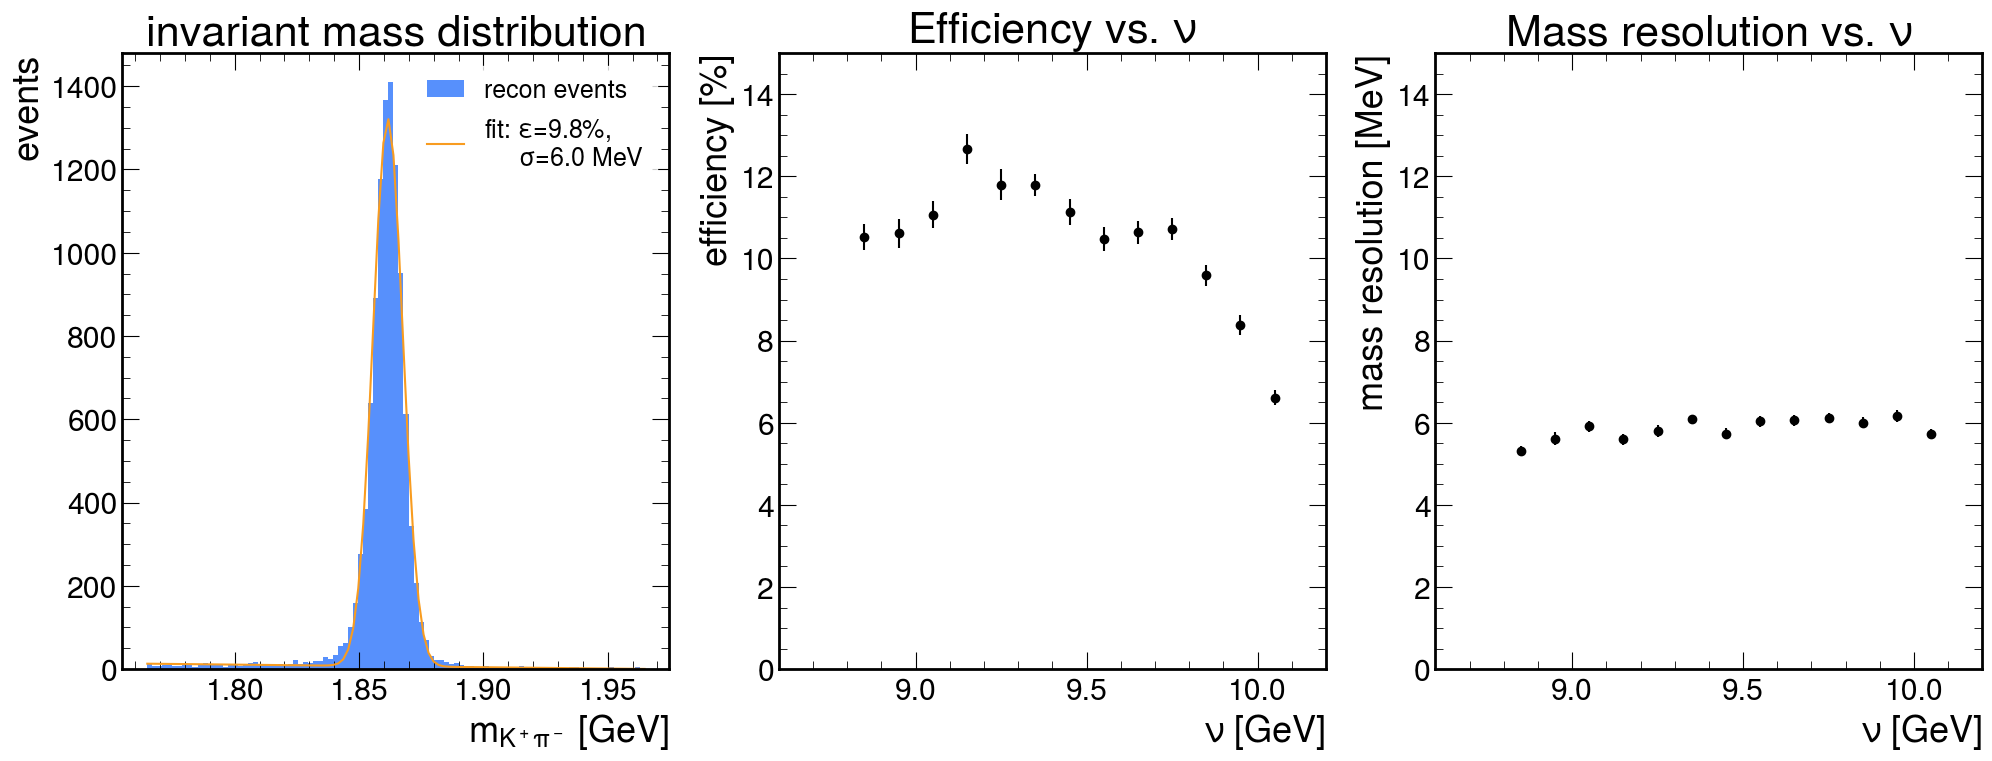

In [44]:

deg=np.pi/180
fig, axs=plt.subplots(1,3,figsize=(24,8))

selection=(df['topo']==0)&(df['mvtx_status']==63)
for p in "K pi".split():
    for i in range(3):
        selection=selection&(np.abs(np.arctan2(df[f'{p}_py'],df[f'{p}_px'])-np.arctan2(df[f'{p}_MVTX_y{i}'],df[f'{p}_MVTX_x{i}']))\
                     <3*np.pi/180/np.sin(np.arctan2(np.hypot(df[f'{p}_px'],df[f'{p}_py']),df[f'{p}_pz'])))
        #selection=selection&(np.abs(np.arctan2(np.hypot(df[f'{p}_px'],df[f'{p}_py']),df[f'{p}_pz']))-np.abs(np.arctan2(np.hypot(df[f'{p}_MVTX_x{i}'],df[f'{p}_MVTX_y{i}']),df[f'{p}_MVTX_z{i}']))
        #             <3*np.pi/180)
titles="CLAS12", "CLAS12 with MVTX acceptance"
plt.sca(axs[0])
y, x, _ = plt.hist(df['pair_mass_new'][selection],bins=np.linspace(m_D0bar-.10,m_D0bar+.10, 100),
                      label='recon events')
print(sum(y)/100000)
bc=(x[1:]+x[:-1])/2
p0=(100, m_D0bar, 0.03, 0,0)
fnc=gauss_plus_poly
dy=np.sqrt(y)+(y==0)
coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
dx=x[1]-x[0]
label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
xx=np.linspace(x[0],x[-1],100)
plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
plt.xlabel("$m_{K^+\pi^-}$ [GeV]")
plt.ylabel("events")
plt.legend(fontsize=18)
plt.title("invariant mass distribution")



    
selection=(df['topo']==0)&(df['mvtx_status']==63)
for p in "K pi".split():
    for i in range(3):
        selection=selection&(np.abs(np.arctan2(df[f'{p}_py'],df[f'{p}_px'])-np.arctan2(df[f'{p}_MVTX_y{i}'],df[f'{p}_MVTX_x{i}']))\
                     <3*np.pi/180/np.sin(np.arctan2(np.hypot(df[f'{p}_px'],df[f'{p}_py']),df[f'{p}_pz'])))
        #selection=selection&(np.abs(np.arctan2(np.hypot(df[f'{p}_px'],df[f'{p}_py']),df[f'{p}_pz'])-np.arctan2(np.hypot(df[f'{p}_MVTX_x{i}'],df[f'{p}_MVTX_y{i}']),df[f'{p}_MVTX_z{i}']+50))
        #         <3*np.pi/180)
plt.sca(axs[1])
partitions=np.linspace(8.7,10.1,15)
eff=[]
deff=[]
res=[]
dres=[]
nu=[]

events_per_nu_bin=[[np.int64(1199), np.int64(4050), np.int64(4942), np.int64(5962), np.int64(6447), np.int64(7101), np.int64(7452), np.int64(7257), np.int64(7846), np.int64(7781), np.int64(8140), np.int64(8022), np.int64(8461), np.int64(8351), np.int64(6989)],
    [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(4533), np.int64(9593), np.int64(12094), np.int64(13810), np.int64(15344), np.int64(16032), np.int64(16731), np.int64(11863)],
    [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(4672), np.int64(9597), np.int64(11926), np.int64(13631), np.int64(15285), np.int64(16047), np.int64(16953), np.int64(11889)]][j]
print(sum(events_per_nu_bin))
for i,(numin,numax) in list(enumerate(zip(partitions[:-1],partitions[1:])))[1:]:
    y, x = np.histogram(df['pair_mass_new'][selection&(df['nu']>numin)&(df['nu']<numax)],bins=np.linspace(m_D0bar-.10,m_D0bar+.10, 100))
    #print(y,x)
    dx=x[1]-x[0]
    bc=(x[1:]+x[:-1])/2
    p0=(100, m_D0bar, 0.03, 0,0)
    fnc=gauss_plus_poly
    dy=np.sqrt(y)+(y==0)
    coeff, var_matrix = curve_fit(fnc, np.array(bc), np.array(y), p0=p0,sigma=np.array(dy))
    eff.append(100*coeff[0]/events_per_nu_bin[i]/dx)
    deff.append(100*var_matrix[0][0]**.5/events_per_nu_bin[i]/dx)

    res.append(1000*np.abs(coeff[2]))
    dres.append(1000*var_matrix[2][2]**.5)
    
    nu.append((numin+numax)/2)

plt.title("Efficiency vs. $\\nu$")
plt.errorbar(nu, eff,deff, ls='', marker='o', color='krb'[j])
plt.xlabel("$\\nu$ [GeV]")
plt.ylabel("efficiency [%]")
plt.ylim(0,15)
plt.xlim(8.6,10.2)

plt.sca(axs[2])
plt.title("Mass resolution vs. $\\nu$")
plt.errorbar(nu, res,dres, ls='', marker='o', color='krb'[j])
plt.xlabel("$\\nu$ [GeV]")
plt.ylabel("mass resolution [MeV]")
plt.ylim(0,15)
plt.xlim(8.6,10.2)



plt.savefig("images/mass_distibution_MC.pdf")
plt.show()

100000
0.10385
0.10365
0.1088
0.1117
0.11085


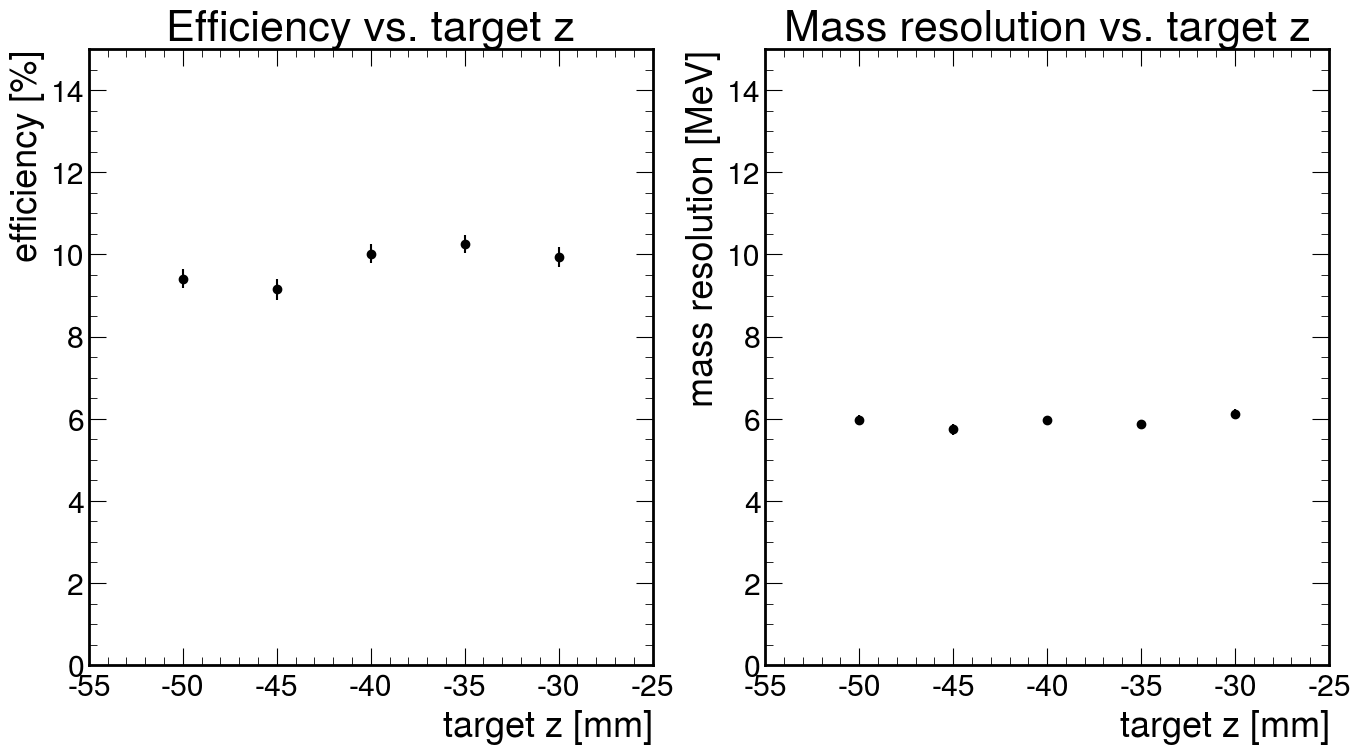

In [45]:
partitions=np.linspace(-52.5, -27.5, 6)/10

selection=(df['topo']==0)&(df['mvtx_status']==63)
for p in "K pi".split():
    for i in range(3):
        selection=selection&(np.abs(np.arctan2(df[f'{p}_py'],df[f'{p}_px'])-np.arctan2(df[f'{p}_MVTX_y{i}'],df[f'{p}_MVTX_x{i}']))\
                     <3*np.pi/180/np.sin(np.arctan2(np.hypot(df[f'{p}_px'],df[f'{p}_py']),df[f'{p}_pz'])))

fig, axs=plt.subplots(1,2,figsize=(16,8))
eff=[]
deff=[]
res=[]
dres=[]
z=[]
events_per_foil=np.array([1e5/5]*5)
print(sum(events_per_nu_bin))
for i,(zmin,zmax) in enumerate(zip(partitions[:-1],partitions[1:])):
    y, x = np.histogram(df['pair_mass_new'][selection&(df['foil_z_mc']>zmin)&(df['foil_z_mc']<zmax)],bins=np.linspace(m_D0bar-.10,m_D0bar+.10, 100))
    print(sum(y)/20000)
    dx=x[1]-x[0]
    bc=(x[1:]+x[:-1])/2
    p0=(100, m_D0bar, 0.01, 0,0)
    fnc=gauss_plus_poly
    dy=np.sqrt(y)+(y==0)
    coeff, var_matrix = curve_fit(fnc, np.array(bc), np.array(y), p0=p0,sigma=np.array(dy))
    eff.append(100*coeff[0]/events_per_foil[i]/dx)
    deff.append(100*var_matrix[0][0]**.5/events_per_foil[i]/dx)

    res.append(1000*coeff[2])
    dres.append(1000*var_matrix[2][2]**.5)
    
    z.append((zmin+zmax)/2*10)

plt.sca(axs[0])
plt.title("Efficiency vs. target z")
plt.errorbar(z, eff,deff, ls='', marker='o', color='k')
plt.xlabel("target $z$ [mm]")
plt.ylabel("efficiency [%]")
plt.ylim(0, 15)
plt.xlim(-55,-25)

plt.sca(axs[1])
plt.title("Mass resolution vs. target z")
plt.errorbar(z, res,dres, ls='', marker='o', color='k')
plt.xlabel("target $z$ [mm]")
plt.ylabel("mass resolution [MeV]")
plt.ylim(0, 15)
plt.xlim(-55,-25)



plt.savefig("images/mass_distibution_MC_foils.pdf")

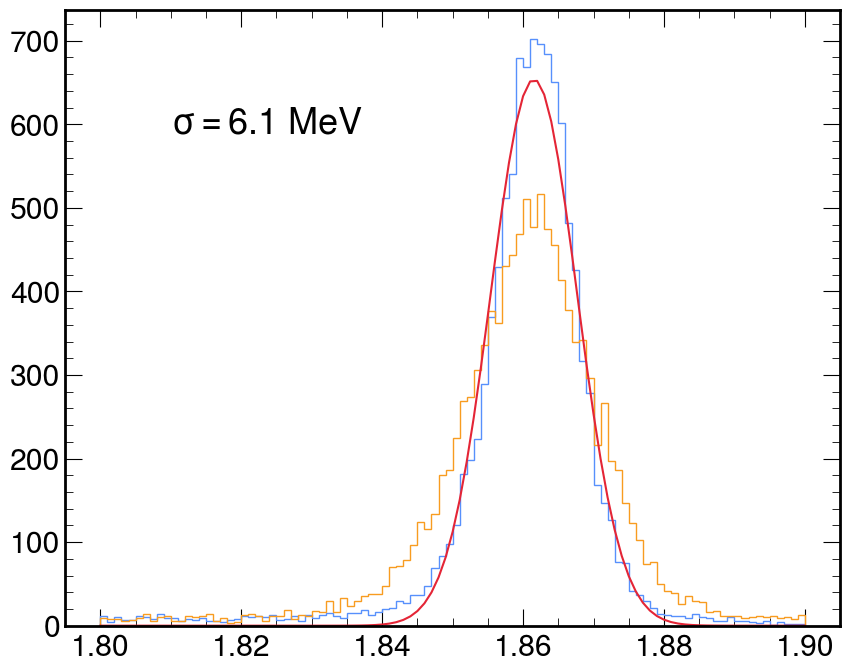

In [20]:
df['K_px_new']=df['K_p']*-np.sin(psi1)*np.sin(np.arctan(df['K_ROC']/Kp_t_recon))
df['K_py_new']=df['K_p']*np.cos(psi1)*np.sin(np.arctan(df['K_ROC']/Kp_t_recon))
df['K_pz_new']=df['K_p']*np.cos(np.arctan(df['K_ROC']/Kp_t_recon))

df['pi_px_new']=df['pi_p']*-np.sin(psi2)*np.sin(np.arctan(df['pi_ROC']/pim_t_recon))
df['pi_py_new']=df['pi_p']*np.cos(psi2)*np.sin(np.arctan(df['pi_ROC']/pim_t_recon))
df['pi_pz_new']=df['pi_p']*np.cos(np.arctan(df['pi_ROC']/pim_t_recon))

df['pair_mass_new']=df.eval("sqrt(-(K_px_new+pi_px_new)**2-(K_py_new+pi_py_new)**2-(K_pz_new+pi_pz_new)**2+(sqrt(.4936**2+K_px_new**2+K_py_new**2+K_pz_new**2)+sqrt(.1396**2+pi_px_new**2+pi_py_new**2+pi_pz_new**2))**2)")
y,x,_=plt.hist(df.query("mvtx_status==63")["pair_mass_new"], bins=100, range=(1.8,1.9),histtype='step')
df['pair_mass_old']=df.query("mvtx_status==63").eval("sqrt(-(K_px+pi_px)**2-(K_py+pi_py)**2-(K_pz+pi_pz)**2+(sqrt(.4936**2+K_px**2+K_py**2+K_pz**2)+sqrt(.1396**2+pi_px**2+pi_py**2+pi_pz**2))**2)")
plt.hist(df["pair_mass_old"], bins=100, range=(1.8,1.9), histtype='step')


bc=(x[1:]+x[:-1])/2
gauss= lambda x,A,mu,sigma : A*np.exp(-(x-mu)**2/(2*sigma**2))
P,cov=curve_fit(gauss, bc,y,(1000,1.864,0.020),sigma=np.sqrt(y)+1*(y==0))
sigma=P[2]
plt.text(1.81, plt.gca().get_ylim()[1]*.8, f"$\\sigma={sigma*1000:.1f}$ MeV")
plt.plot(x,gauss(x,*P))

plt.show()

# plt.hist2d(df.K_px_new, df.K_px,bins=100, range=((-3,3),(-3,3))); plt.show()
# plt.hist2d(df.K_py_new, df.K_py, bins=100, range=((-3,3),(-3,3))); plt.show()
# plt.hist2d(df.K_pz_new, df.K_pz, bins=100, range=((-5,5),(-5,5))); plt.show()

# plt.hist2d(df.pi_px_new, df.pi_px,bins=100, range=((-3,3),(-3,3))); plt.show()
# plt.hist2d(df.pi_py_new, df.pi_py, bins=100, range=((-3,3),(-3,3))); plt.show()
# plt.hist2d(df.pi_pz_new, df.pi_pz, bins=100, range=((-5,5),(-5,5))); plt.show()

# psi1 = results[:, 0]
# psi2 = results[:, 1]




# df['vtx_x'], df['vtx_y'], df['vtx_z']=[(Kp_xc_recon+Kp_ROC_recon*np.cos(psi1)+pim_xc_recon+pim_ROC_recon*np.cos(psi2))/2,
#                                         (Kp_yc_recon+Kp_ROC_recon*np.sin(psi1)+pim_yc_recon+pim_ROC_recon*np.sin(psi2))/2,
#                                         (Kp_z0_recon+Kp_t_recon*psi1+pim_z0_recon+pim_t_recon*psi2)/2]

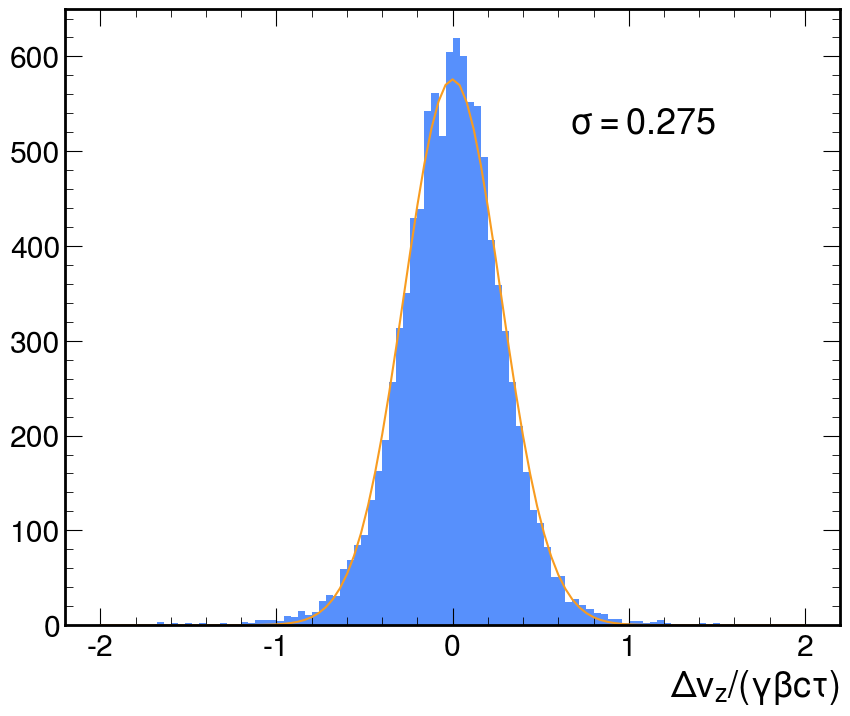

0.2914855788225998


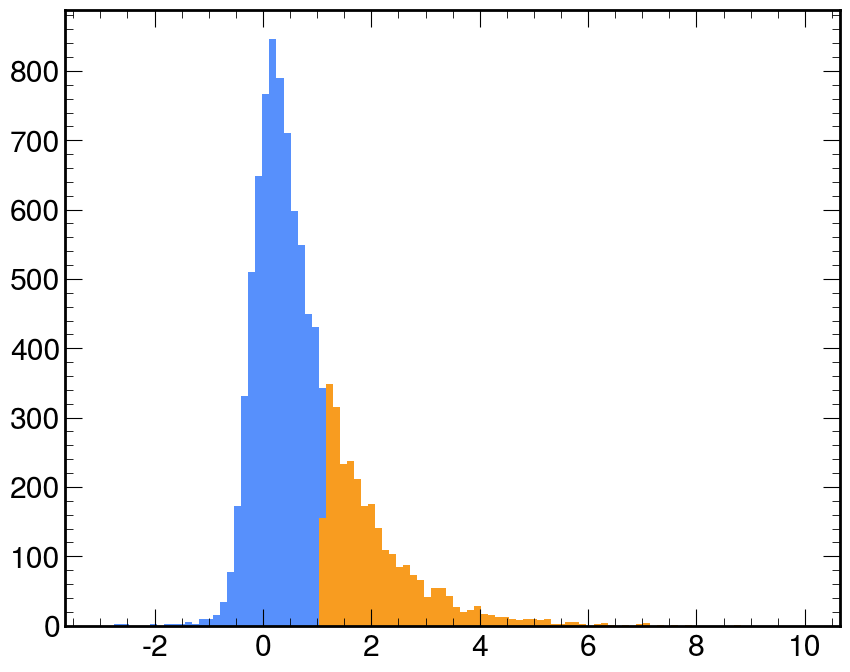

In [543]:
q='pi_th>8.9*3.14159/180 and K_th>8.9*3.14159/180 and mvtx_status==63 and invmass>1.83 and invmass<1.9 and pi_p>0.5 and K_p>0.5'
#q+=" and (vtx_z+100)%5>0.1"
q+=" and pim_ROC_noassist >250 and Kp_ROC_noassist>250"
q+=" and abs(doca)<0.64*3 and pi_th<40*3.14159/180 and K_th<40*3.14159/180"

a=df.query(q).eval("(vtx_z-vtx_z_mc*10)/((K_pz+pi_pz)/1.864*299792458000*410.3e-15)")
y,x,_=plt.hist(a, bins=100, range=(-2,2))
bc=(x[1:]+x[:-1])/2
gauss= lambda x,A,mu,sigma : A*np.exp(-(x-mu)**2/(2*sigma**2))
P,cov=curve_fit(gauss, bc,y,(1000,0,20),sigma=np.sqrt(y)+1*(y==0))
sigma=P[2]
plt.text(plt.gca().get_xlim()[1]*.3, plt.gca().get_ylim()[1]*.8, f"$\\sigma={abs(sigma):.3f}$")
plt.plot(x,gauss(x,*P))
plt.xlabel("$\\Delta v_z/(\\gamma\\beta c\\tau)$")


plt.show()

df["FOM"]=df.eval("((vtx_z+1000+2.5-.05)%5-2.5)/((K_pz+pi_pz)/1.864*299792458000*410.3e-15)")
plt.hist(df.query(q).FOM, bins=100, range=(-3, 10))
plt.hist(df.query(q+f" and FOM>{4*sigma}").FOM, bins=100, range=(-3, 10))
print(len(df.query(q+f" and FOM>{4*sigma}"))/len(df.query(q)))
#plt.axvline(4*sigma, color='tab:orange')
#plt.title(titles[i])


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100)),
 array([-55. , -54.7, -54.4, -54.1, -53.8, -53.5, -53.2, -52.9, -52.6,
        -52.3, -52. , -51.7, -51.4, -51.1, -50.8, -50.5, -50.2, -49.9,
        -49.6, -49.3, -49. , -48.7, -48.4, -48.1, -47.8, -47.5, -47.2,
        -46.9, -46.6, -46.3, -46. , -45.7, -45.4, -45.1, -44.8, -44.5,
        -44.2, -43.9, -43.6, -43.3, -43. , -42.7, -42.4, -42.1, -41.8,
        -41.5, -41.2, -40.9, -40.6, -40.3, -40. , -39.7, -39.4, -39.1,
        -38.8, -38.5, -38.2, -37.9, -37.6, -37.3, -37. , -36.7, -36.4,
        -36.1, -35.8, -35.5, -35.2, -34.9, -34.6, -34.3, -34. , -33.7,
        -33.4, -33.1, -32.8, -32.5, -32.2, -31.9, -31.6, -31.3, -31. ,
        -30.7, -30.4, -30.1, -29.8, -29.5, -29.2, -28.9, -28.6, -28.3,
        -28. , -27.7, -

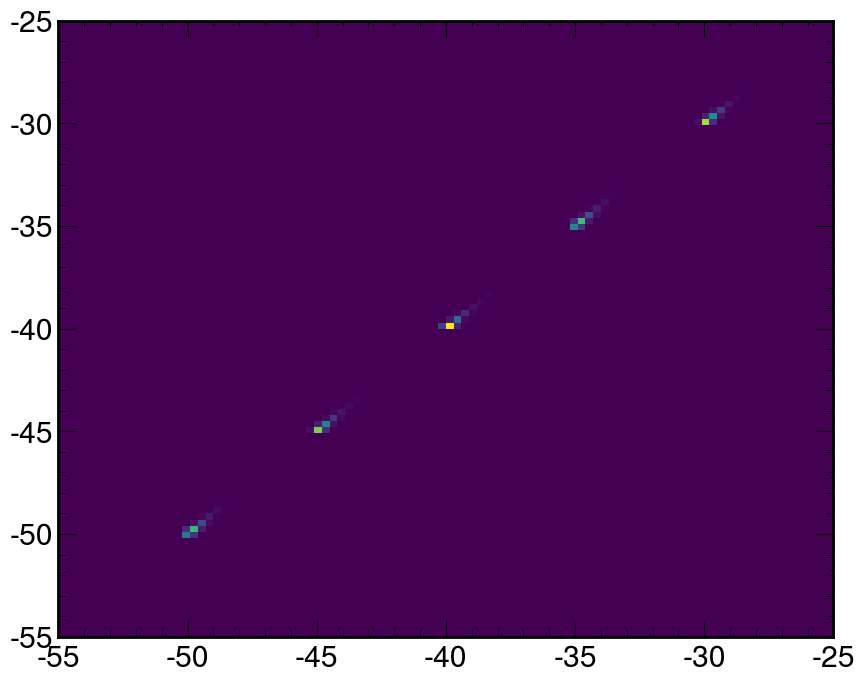

In [529]:
plt.hist2d(df.query(q).vtx_z, df.query(q).vtx_z_mc*10, bins=100, range=[(-55, -25)]*2)

In [473]:
np.sign

<ufunc 'sign'>

(0.0, 2000.0)

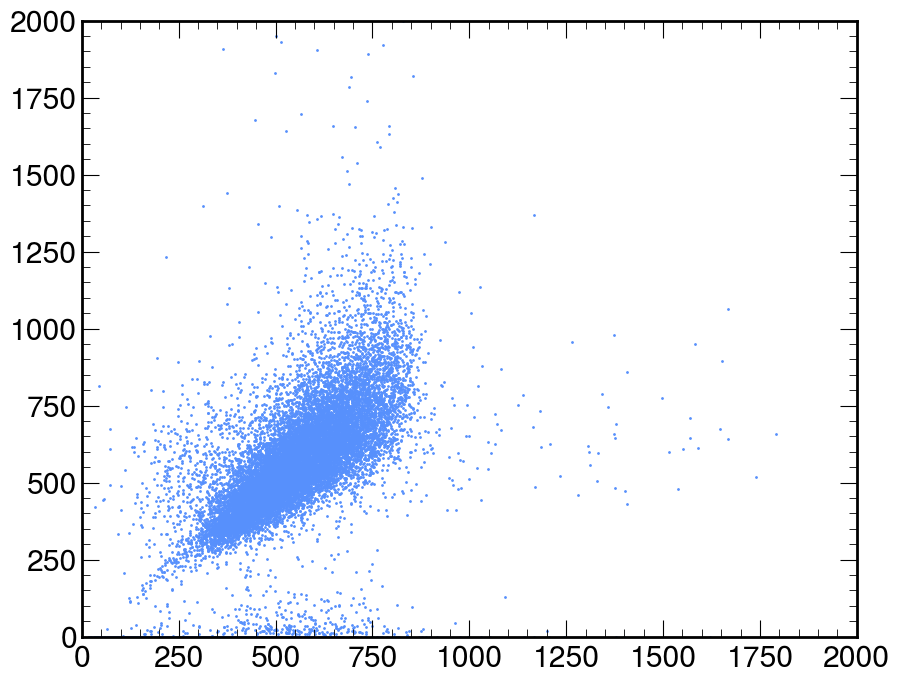

In [503]:
plt.scatter(Kp_ROC_recon,df.Kp_ROC_noassist,1)
plt.ylim(0, 2000)
plt.xlim(0, 2000)


(array([ 16.,  18.,  11.,  23.,  17.,  25.,  31.,  20.,  23.,  31.,  25.,
         24.,  31.,  34.,  30.,  34.,  42.,  43.,  51.,  58.,  64.,  62.,
         78.,  82.,  89., 106., 119., 119., 145., 154., 154., 205., 204.,
        227., 251., 296., 326., 330., 383., 412., 460., 487., 509., 554.,
        665., 677., 708., 762., 792., 715., 759., 744., 752., 673., 682.,
        662., 543., 502., 458., 485., 356., 330., 280., 283., 239., 222.,
        224., 162., 176., 129., 124., 117.,  91.,  96.,  83.,  73.,  78.,
         63.,  54.,  51.,  57.,  51.,  45.,  43.,  40.,  37.,  35.,  30.,
         24.,  35.,  28.,  28.,  16.,  24.,  20.,  14.,   7.,  17.,  14.,
          7.]),
 array([-0.01  , -0.0098, -0.0096, -0.0094, -0.0092, -0.009 , -0.0088,
        -0.0086, -0.0084, -0.0082, -0.008 , -0.0078, -0.0076, -0.0074,
        -0.0072, -0.007 , -0.0068, -0.0066, -0.0064, -0.0062, -0.006 ,
        -0.0058, -0.0056, -0.0054, -0.0052, -0.005 , -0.0048, -0.0046,
        -0.0044, -0.0042, -0.004 ,

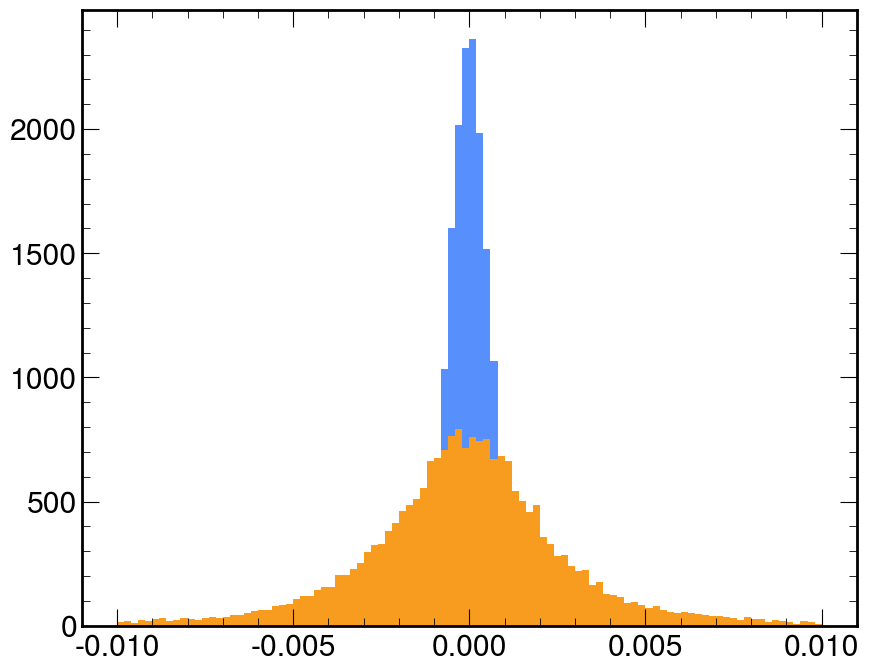

In [470]:
#selection=(pim_ROC_recon>250)&df.query("mvtx_status==63")
plt.hist(np.arctan(np.abs(pim_ROC_recon/pim_t_recon))-df.eval("arctan2(sqrt(pi_px_mc**2+pi_py_mc**2),pi_pz_mc)"),bins=100, range=(-.01,.01))
plt.hist(df.pi_th-df.eval("arctan2(sqrt(pi_px_mc**2+pi_py_mc**2),pi_pz_mc)"),bins=100, range=(-.01,.01))
#plt.xlim(-1,1)

# now estimate how often tracks will be mis-paired with one another

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


nan nan


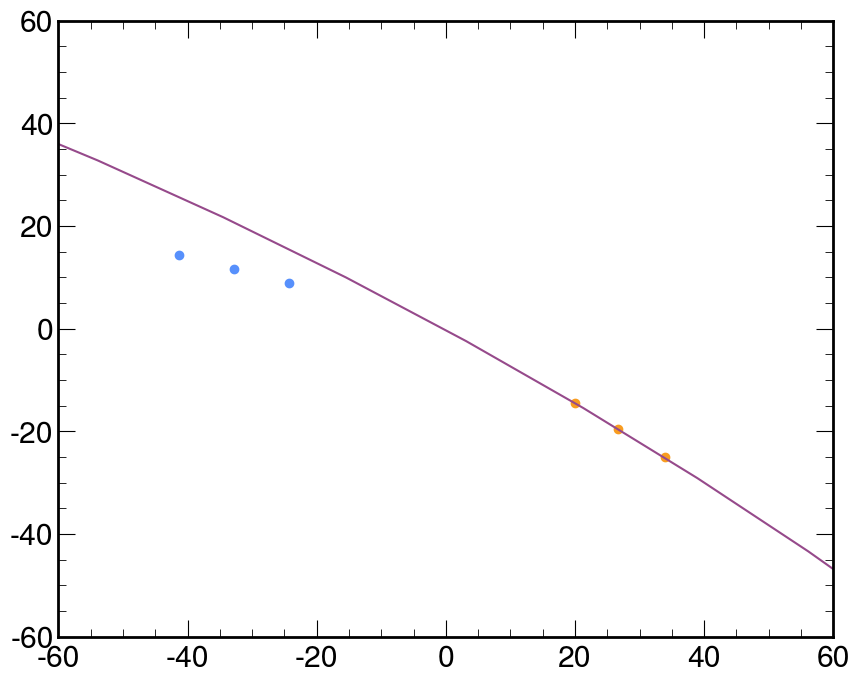

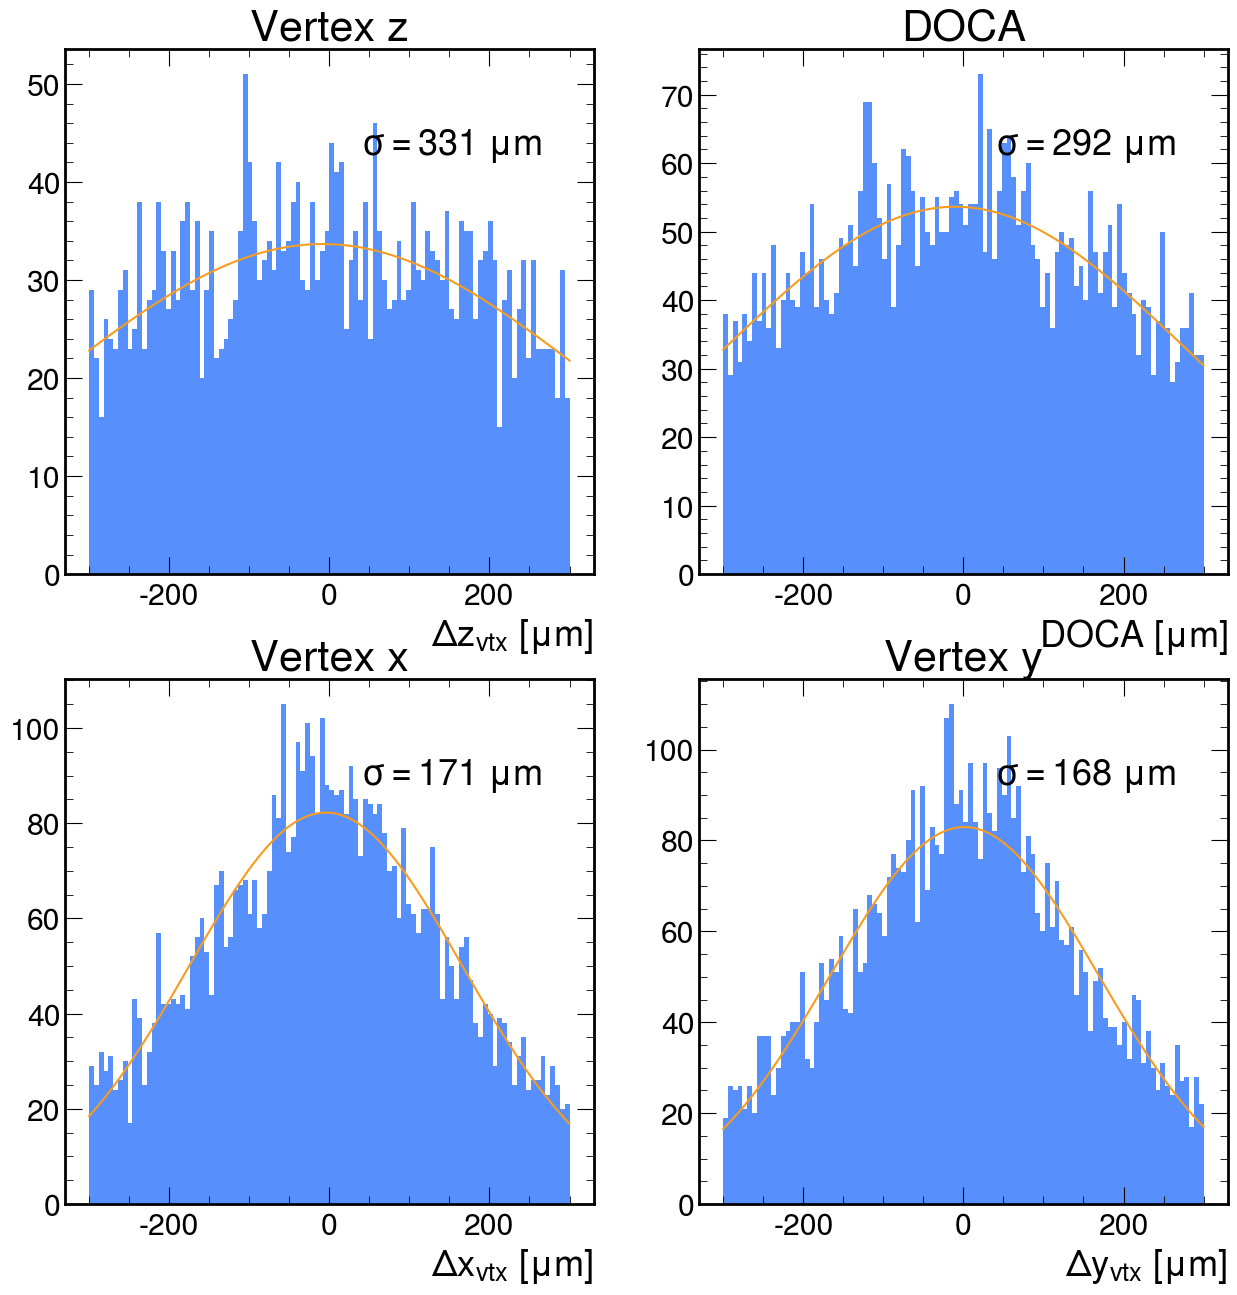

In [485]:
for df in arrays_nopid,:# arrays_nopid_pi0, arrays_nopid_gamma:
    df=ak.to_dataframe(df).copy()
    #first smear, since the resolution effects are not yet present in the simulation
    for p in 'K pi'.split():
        for i in range(3):
            smear=0.005
            for x in 'xyz':
                df[f'{p}_MVTX_{x}{i}_smear']=df[f'{p}_MVTX_{x}{i}']+np.random.normal(0,smear,len(df))
        #mix together tracks from different events
        if p=='K':
            for i in range(3):
                for x in 'xyz':
                    df[f'{p}_MVTX_{x}{i}_smear']=np.roll(df[f'{p}_MVTX_{x}{i}_smear'],5)

    #determine radius of curvature from the DC pt:

    for p in 'K pi'.split():
        df[f'{p}_ROC']=np.hypot(df[f'{p}_px'],df[f'{p}_py'])/(.299792458*5.0)*1000
    
    Kp_xc_recon,Kp_yc_recon,Kp_ROC_recon,Kp_t_recon,Kp_z0_recon=findHelix(*(df['K_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), 
                                                                     df['K_ROC'])
    pim_xc_recon,pim_yc_recon,pim_ROC_recon,pim_t_recon,pim_z0_recon=findHelix(*(df['pi_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), 
                                                                           df['pi_ROC'])
    _,_,df['pim_ROC_noassist'],_,_= findHelix(*(df['pi_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), None)
    _,_,df['Kp_ROC_noassist'],_,_= findHelix(*(df['K_MVTX_'+a+'_smear'] for a in 'x0 y0 z0 x1 y1 z1 x2 y2 z2'.split()), None)

    #first determine where they intersect in the projected circles.  Then refine the estimate
    intersections=circle_intersection_points(Kp_xc_recon,Kp_yc_recon,Kp_ROC_recon, pim_xc_recon,pim_yc_recon,pim_ROC_recon)

    #now refine the position estimate
    psi1=np.atan2(intersections[0][1]-Kp_yc_recon,intersections[0][0]-Kp_xc_recon)
    psi2=np.atan2(intersections[0][1]-pim_yc_recon,intersections[0][0]-pim_xc_recon)


    #function that needs to be minimized to get the two points on the helices closest to one another
    def fnc(psis, xc1, yc1, r1, t1, z01, xc2, yc2, r2, t2, z02): 
        psi1, psi2 = psis 
        term_x = (xc1 + r1 * np.cos(psi1) - xc2 - r2 * np.cos(psi2))**2
        term_y = (yc1 + r1 * np.sin(psi1) - yc2 - r2 * np.sin(psi2))**2 
        term_z = (z01 + t1 * psi1 - z02 - t2 * psi2)**2
        return term_x + term_y + term_z
    
    # Run optimization sequentially for every event in your 1D arrays
    results = []
    for i in range(len(psi1)):
        # Grab the constants for ONLY event 'i'
        event_args = (
            Kp_xc_recon[i], Kp_yc_recon[i], Kp_ROC_recon[i], Kp_t_recon[i], Kp_z0_recon[i],
            pim_xc_recon[i], pim_yc_recon[i], pim_ROC_recon[i], pim_t_recon[i], pim_z0_recon[i]
        )
        #print(fnc((psi1[i],psi2[i]), *event_args))
        res = minimize(fun=fnc, x0=(psi1[i], psi2[i]), args=event_args, bounds=((psi1[i]-.3, psi1[i]+.3),(psi2[i]-.3,psi2[i]+.3)))
        #print(res)
        results.append(res.x) # Saves [opt_psi1, opt_psi2] for this loop
        #print((psi1[i]-res.x[0]),(psi2[i]-res.x[1]))
        #if i==10: break
    # Convert results into two clean 1D arrays
    results = np.array(results)
    psi1 = results[:, 0]
    psi2 = results[:, 1]
    


    
    df['vtx_x'], df['vtx_y'], df['vtx_z']=[(Kp_xc_recon+Kp_ROC_recon*np.cos(psi1)+pim_xc_recon+pim_ROC_recon*np.cos(psi2))/2,
                                            (Kp_yc_recon+Kp_ROC_recon*np.sin(psi1)+pim_yc_recon+pim_ROC_recon*np.sin(psi2))/2,
                                            (Kp_z0_recon+Kp_t_recon*psi1+pim_z0_recon+pim_t_recon*psi2)/2]
    df['doca']=np.sqrt((Kp_xc_recon+Kp_ROC_recon*np.cos(psi1)-pim_xc_recon-pim_ROC_recon*np.cos(psi2))**2+\
                                            (Kp_yc_recon+Kp_ROC_recon*np.sin(psi1)-pim_yc_recon-pim_ROC_recon*np.sin(psi2))**2+\
                                            (Kp_z0_recon+Kp_t_recon*psi1-pim_z0_recon-pim_t_recon*psi2)**2)*\
                                            np.sign(Kp_z0_recon+Kp_t_recon*psi1-pim_z0_recon-pim_t_recon*psi2)
    

    i=3
    for p in 'K pi'.split():
        #plot the hits
        plt.plot(*[[df[f'{p}_MVTX_{a}{j}'][i] for j in (0,1,2)] for a in 'xy'], ls ='', marker='o')
        ph=np.linspace(-np.pi, np.pi, 180)
    plt.plot(Kp_xc_recon[i]+np.cos(ph)*Kp_ROC_recon[i],Kp_yc_recon[i]+np.sin(ph)*Kp_ROC_recon[i])
    plt.plot(pim_xc_recon[i]+np.cos(ph)*pim_ROC_recon[i],pim_yc_recon[i]+np.sin(ph)*pim_ROC_recon[i])
    print(intersections[0][0][i],intersections[0][1][i])
    plt.plot(intersections[0][0][i],intersections[0][1][i], marker='x')
        
    plt.xlim(-60,60)
    plt.ylim(-60,60)
    plt.show()

    
    #selection=(df.mvtx_status==63)&(df.pi_th>8.9*np.pi/180)&(df.K_th>8.9*np.pi/180)&(df.invmass>1.83)&(df.invmass<1.9)
    fields="vtx_z-vtx_z_mc*10 doca vtx_x-vtx_x_mc*10 vtx_y-vtx_y_mc*10".split()
    labels="$\\Delta z_{\\rm vtx}$;DOCA;$\\Delta x_{\\rm vtx}$;$\\Delta y_{\\rm vtx}$".split(';')
    titles="Vertex z;DOCA;Vertex x;Vertex y".split(";")
    fig, axs=plt.subplots(2,2, figsize=(15,15))
    for i in range(4):
        plt.sca(axs[i//2][i%2])
        q='pi_th>8.9*3.14159/180 and K_th>8.9*3.14159/180 and mvtx_status==63 and invmass>1.83 and invmass<1.9 and pi_p>0.5 and K_p>0.5 and mvtx_status==63'
        #q+=" and (vtx_z+100)%5>0.1"
        q+=" and pim_ROC_noassist >250 and Kp_ROC_noassist>250"
        a=df.query(q).eval(fields[i])*1000
        y,x,_=plt.hist(a, bins=100, range=(-300,300))
        bc=(x[1:]+x[:-1])/2
        gauss= lambda x,A,mu,sigma : A*np.exp(-(x-mu)**2/(2*sigma**2))
        P,cov=curve_fit(gauss, bc,y,(1000,0,20),sigma=np.sqrt(y)+1*(y==0))
        sigma=P[2]
        plt.text(40, plt.gca().get_ylim()[1]*.8, f"$\\sigma={sigma:.0f}$ $\mu$m")
        plt.plot(x,gauss(x,*P))
        plt.xlabel(labels[i]+" [$\\mu$m]")
        plt.title(titles[i])
        #plt.legend()
    #plt.tight_layout()
    plt.savefig("mismatch.pdf")
    
    #print(np.std(dz[(abs(dz)<500)&(~np.isnan(dz))&selection]))
    plt.show()
    #plt.hist((df.doca)*1000, bins=100, range=(-1000, 1000))
    #plt.show()

In [492]:
q_denom="pi_th>8.9*3.14159/180 and K_th>8.9*3.14159/180 and mvtx_status==63 and invmass>1.83 and invmass<1.9 and pi_p>0.5 and K_p>0.5"
q_num="abs(doca*1000)<3*61 and (vtx_z+100)%5>0.3 and (vtx_z+100)%5<1 and vtx_z<-25 and vtx_z>-50 and abs(vtx_x)<.6 and abs(vtx_y)<.6 and "+q_denom
print(len(df.query(q_num))/len(df))

0.043877595438123015


In [494]:
#plt.hist(df.vtx_x_mc)

# other stuff

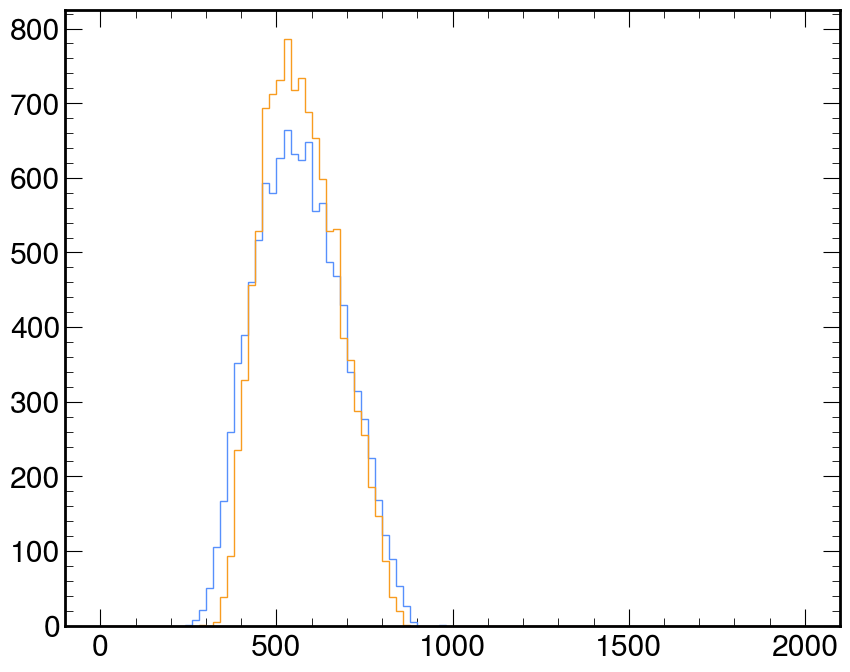

In [189]:
q='pi_th>8.7*3.14159/180 and K_th>8.7*3.14159/180 and mvtx_status==63 and invmass>1.83 and invmass<1.9 and pi_p>0.5 and K_p>0.7'
for p in "K pi".split():
    plt.hist(df.query(q)[f'{p}_ROC'],bins=100, histtype='step', range=(0, 2000))

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   9.,  47.,  75., 118., 187.,
        191., 193., 177., 196., 250., 283., 318., 432., 455., 502., 462.,
        502., 516., 532., 527., 501., 478., 447., 441., 396., 356., 325.,
        252., 269., 223., 179., 125., 103.,  81.,  47.,  50.,  44.,  13.,
         11.,   7.,   3.,   0.,   1.,   1.,   1.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. , 18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5,
        22. , 22.5, 23

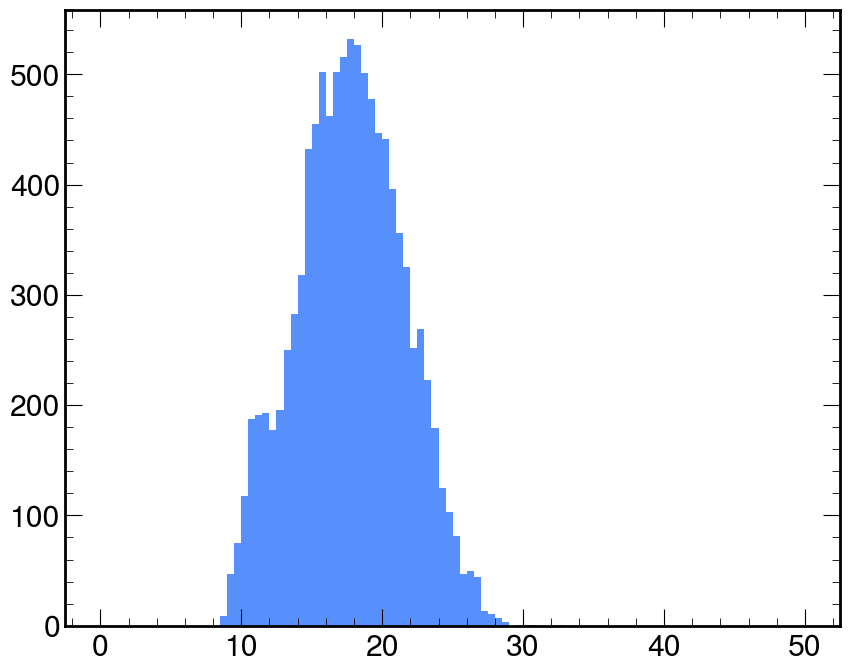

In [488]:
plt.hist(np.minimum(arrays.pi_th,arrays.K_th)[(arrays.invmass>1.83)&(arrays.invmass<1.9)&(arrays.mvtx_status==63)&(arrays.K_p>0.5)&(arrays.pi_p>0.5)]*180/np.pi, bins=100, range=(0,50))

(array([2.468e+03, 1.062e+03, 4.640e+02, 2.270e+02, 1.030e+02, 4.400e+01,
        1.900e+01, 1.000e+01, 5.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.643e+03, 1.588e+03, 7.150e+02,
        3.080e+02, 1.290e+02, 7.000e+01, 3.700e+01, 1.600e+01, 8.000e+00,
        1.000e+00, 5.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.140e+02, 2.477e+03, 1.125e+03, 4.810e+02, 1.980e+02, 9.000e+01,
        5.600e+01, 1.300e+01, 9.000e+00, 4.000e+00, 2.000e+00, 3.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.731e+03, 1.633e+03,
        7.390e+02, 3.010e+02, 1.530e+02, 7.100e+01, 2.600e+01, 1.000e+01,
        1.200e+01, 3.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

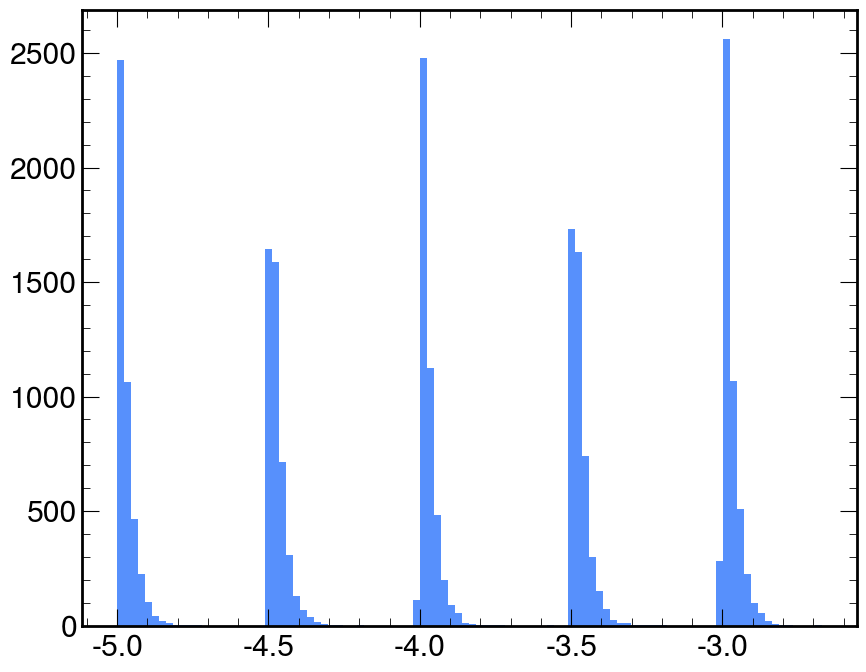

In [117]:
plt.hist(arrays.vtx_z_mc, bins=100)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   1.,   0.,   1.,   3.,   2.,   0.,   0.,   0.,
          2.,   2.,   3.,   3.,   3.,   4.,   1.,   4.,   2.,   7.,   7.,
          8.,  11.,  19.,  17.,  13.,  15.,  24.,  20.,  38.,  27.,  34.,
         37.,  59.,  50.,  65., 115., 131., 146., 203., 195., 234., 249.,
        322., 338., 368., 382., 417., 411., 451., 467., 461., 538., 511.,
        541., 538., 576., 537., 518., 508., 537., 477., 452., 416., 387.,
        395., 378., 313., 296., 261., 226., 215., 174., 127., 119.,  94.,
         64.,  44.,  25.,   6.,   4.,   1.,   0.,   2.,   1.,   0.,   0.,
          1.]),
 array([-1.17776848e+00, -1.16043533e+00, -1.14310218e+00, -1.12576903e+00,
        -1.10843589e+00, -1.09110274e+00, -1.07376959e+00, -1.05643644e+00,
        -1.03910330e+00, -1.02177015e+00, -1.00443700e+00, -9.87103856e-01,
        -9.69770708e-01, -9.52437561e-01, -9.35104414e-01, -9.17771267e-01,
        -9.004

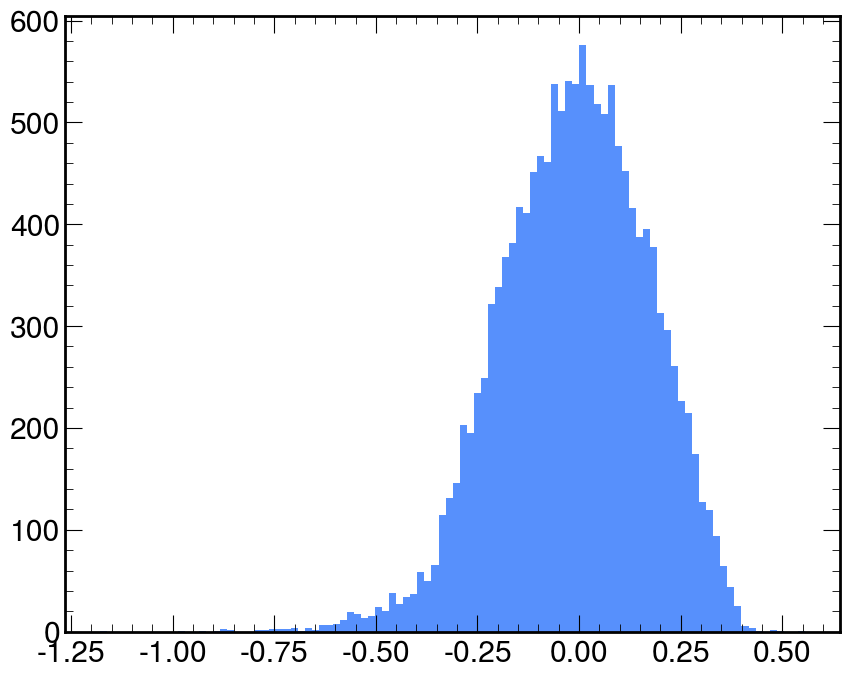

In [16]:
a=arrays_nopid


selection=(a['topo']==0)&(a['mvtx_status']==63)

Y_D0=1/2*np.log((a.K_E+a.pi_E+a.K_pz+a.pi_pz)/(a.K_E+a.pi_E-a.K_pz-a.pi_pz))
Y_cm=1/2*np.log((a.nu+.9383+a.nu)/(.9383))

plt.hist((Y_D0-Y_cm)[selection],bins=100)

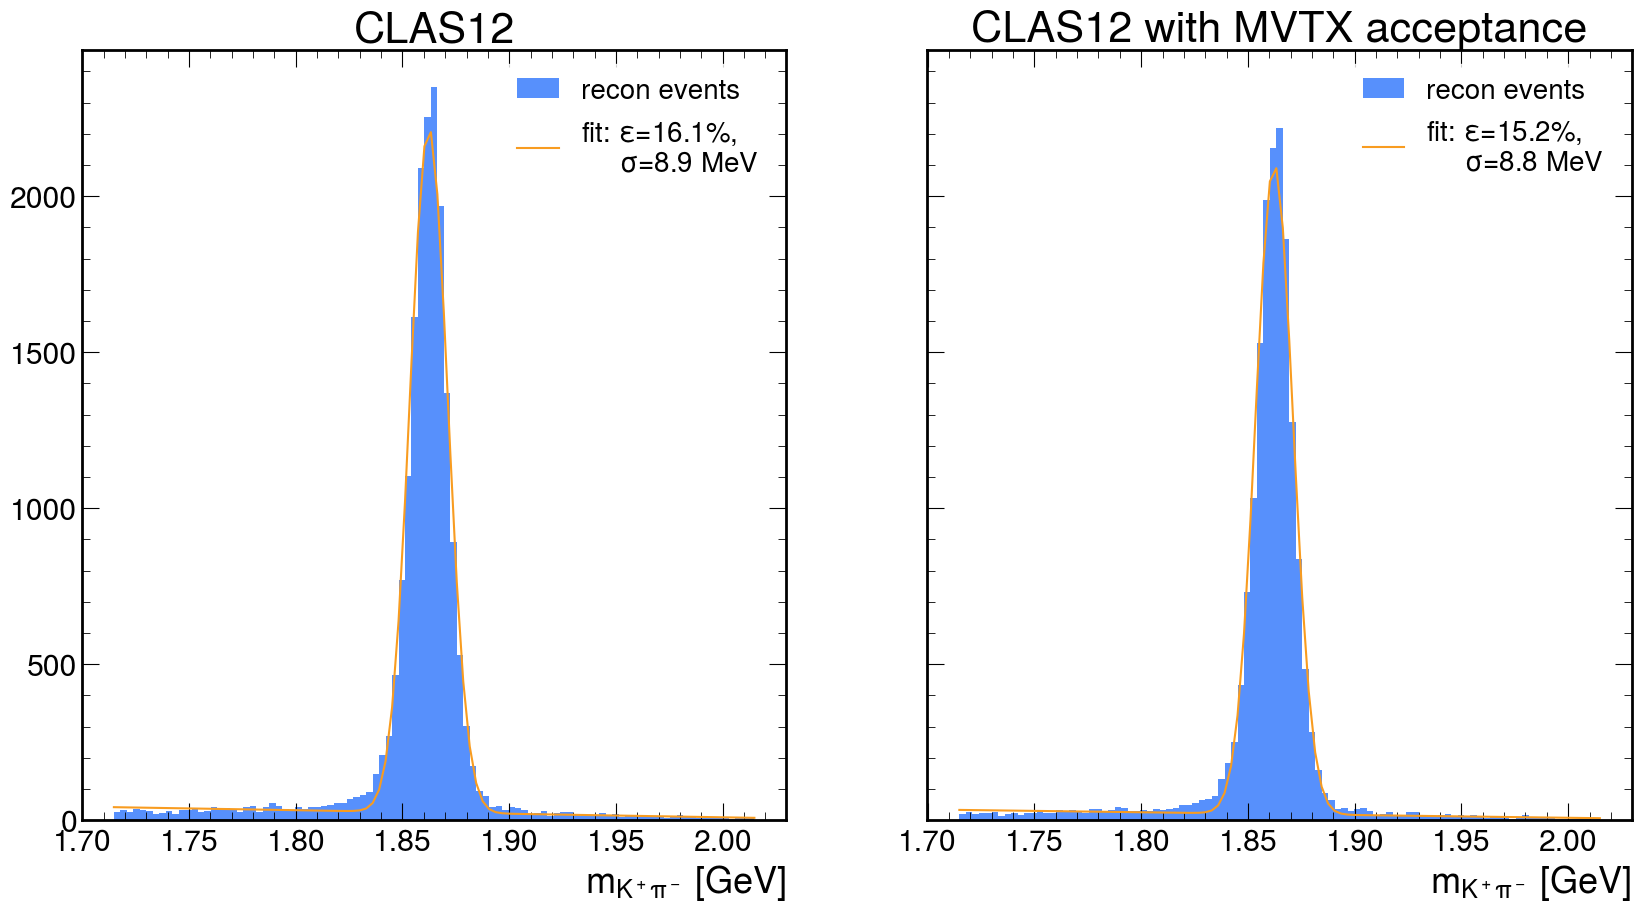

In [9]:
arrays=arrays_nopid
deg=np.pi/180
fig, axs=plt.subplots(1,2,figsize=(20,10),sharey='all')

selections=[(arrays['topo']==0),
            (arrays['topo']==0)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<45*deg)&(arrays['K_th']>8.7*deg)&(arrays['K_th']<45*deg)&\
            (np.sin(arrays['K_th'])*arrays['K_p']>min_pT) &(np.sin(arrays['pi_th'])*arrays['pi_p']>min_pT)]
titles="CLAS12", "CLAS12 with MVTX acceptance"
for i in range(2):
    plt.sca(axs[i])
    y, x, _ = plt.hist(arrays['invmass'][selections[i]],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100),
                          label='recon events')
    bc=(x[1:]+x[:-1])/2
    p0=(100, m_D0bar, 0.03, 0,0)
    fnc=gauss_plus_poly
    dy=np.sqrt(y)+(y==0)
    coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
    dx=x[1]-x[0]
    label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
    xx=np.linspace(x[0],x[-1],100)
    plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
    plt.xlabel("$m_{K^+\pi^-}$ [GeV]")
    plt.legend(fontsize=20)
    plt.title(titles[i])
plt.savefig("images/mass_distibution_MC.pdf")
plt.show()


In [25]:
# for nubin in (8.7,9.0), (9.0, 9.5), (9.50, 10):

#     arrays=arrays_nopid
#     fig, axs=plt.subplots(1,2,figsize=(20,10),sharey='all')
    
#     selections=[(arrays['topo']==0)&(arrays.nu>nubin[0])&(arrays.nu<nubin[1]),
#                 (arrays['topo']==0)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<45*deg)&(arrays['K_th']>8.7*deg)&(arrays['K_th']<45*deg)&\
#                 (np.sin(arrays['K_th'])*arrays['K_p']>min_pT) &(np.sin(arrays['pi_th'])*arrays['pi_p']>min_pT)\
#                &(arrays.nu>nubin[0])&(arrays.nu<nubin[1])]
                    
#     titles="CLAS12", "CLAS12 with MVTX acceptance"
#     for i in range(2):
#         plt.sca(axs[i])
#         y, x, _ = plt.hist(arrays['invmass'][selections[i]],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100),
#                               label='recon events')
#         bc=(x[1:]+x[:-1])/2
#         p0=(100, m_D0bar, 0.03, 0,0)
#         fnc=gauss_plus_poly
#         dy=np.sqrt(y)+(y==0)
#         coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
#         dx=x[1]-x[0]
#         label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
#         xx=np.linspace(x[0],x[-1],100)
#         plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
#         plt.xlabel("$m_{K^+\pi^-}$ [GeV]")
#         plt.legend(fontsize=20)
#         plt.title(titles[i])
#     #plt.savefig("images/mass_distibution_MC.pdf")
#     plt.show()


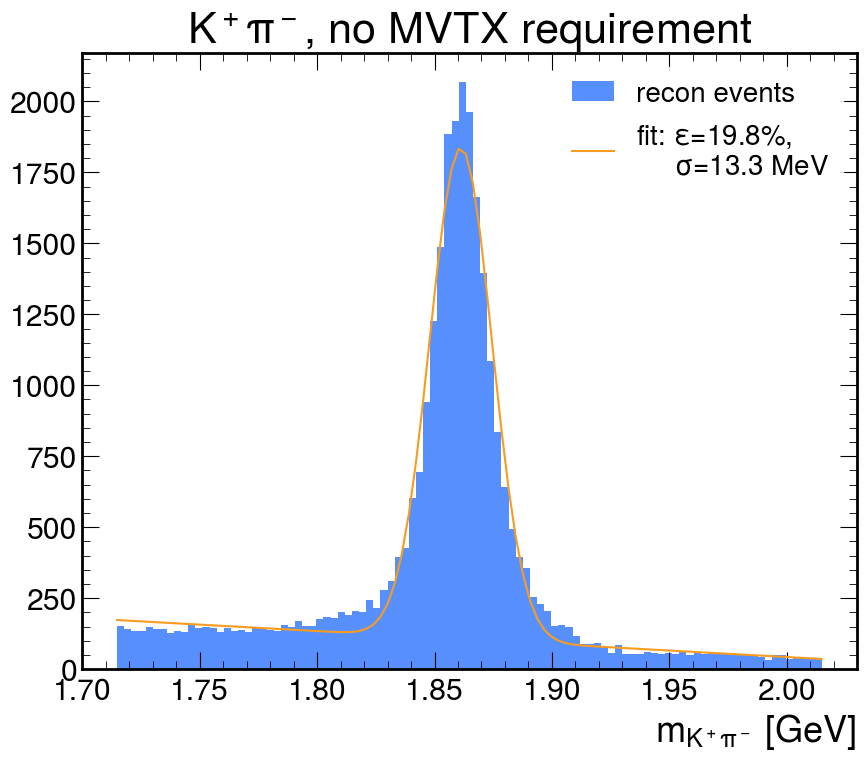

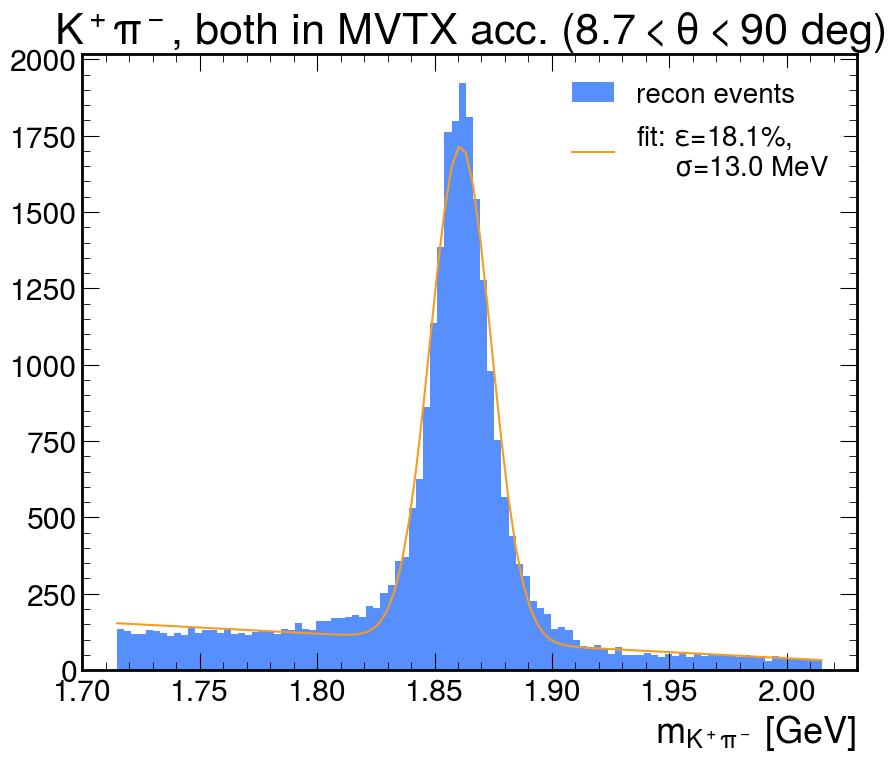

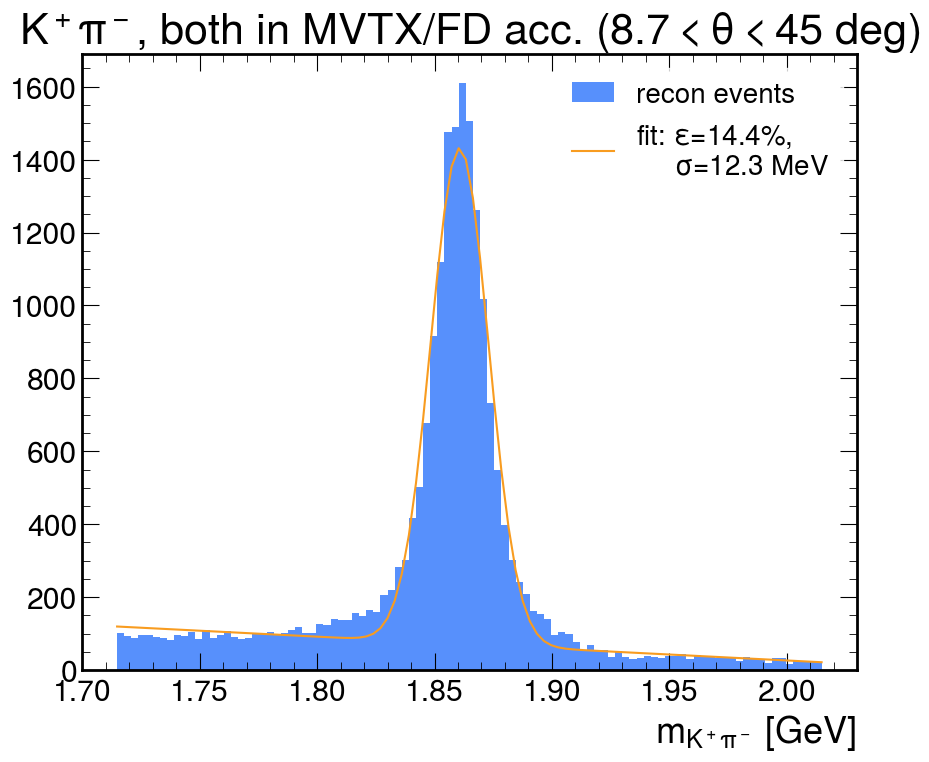

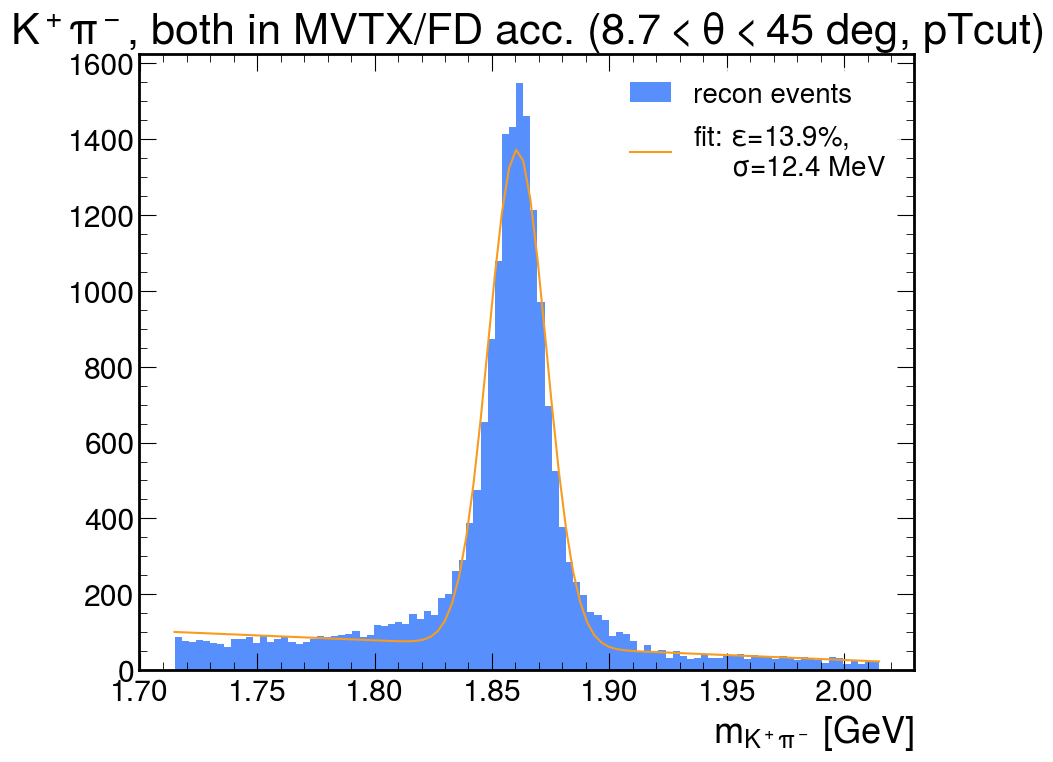

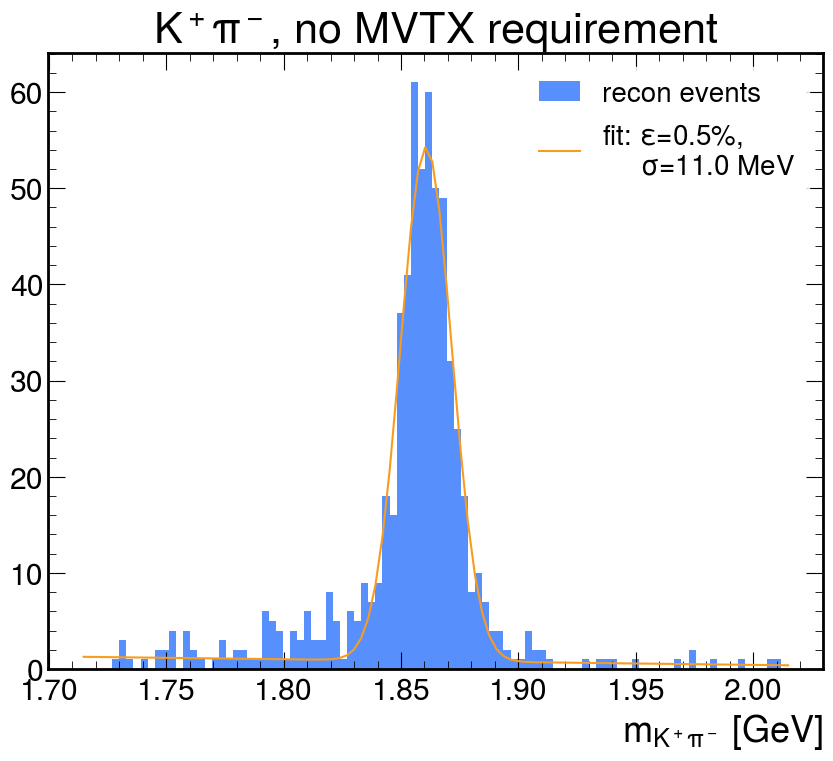

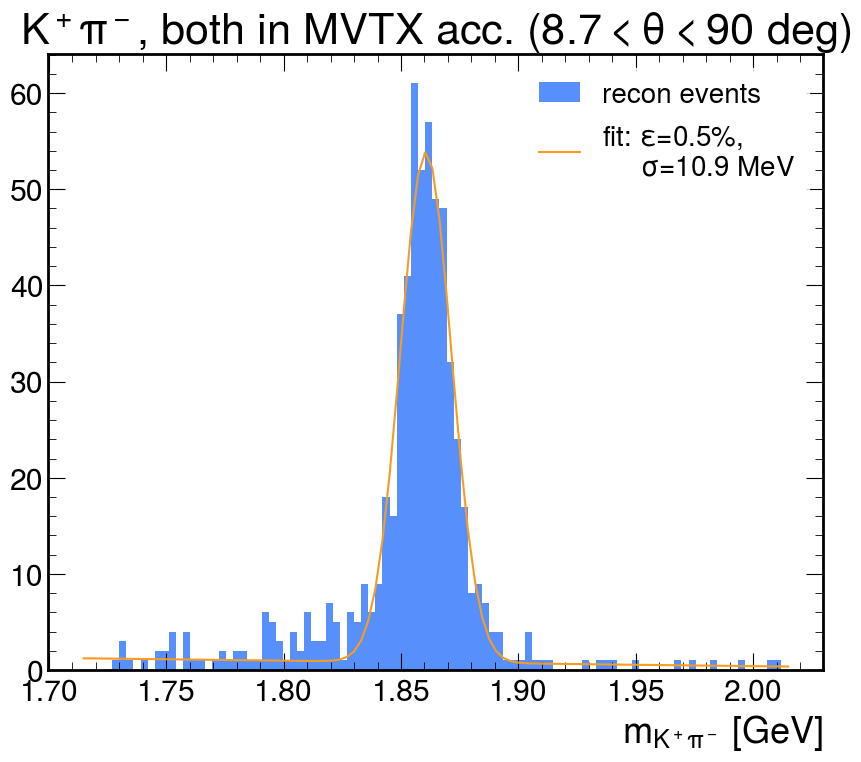

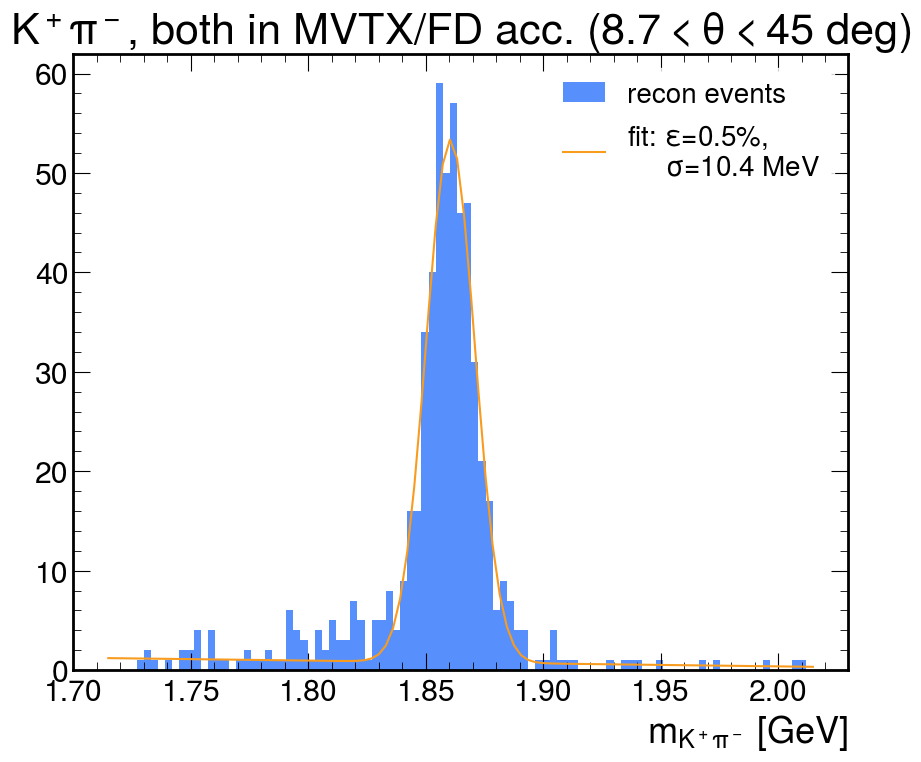

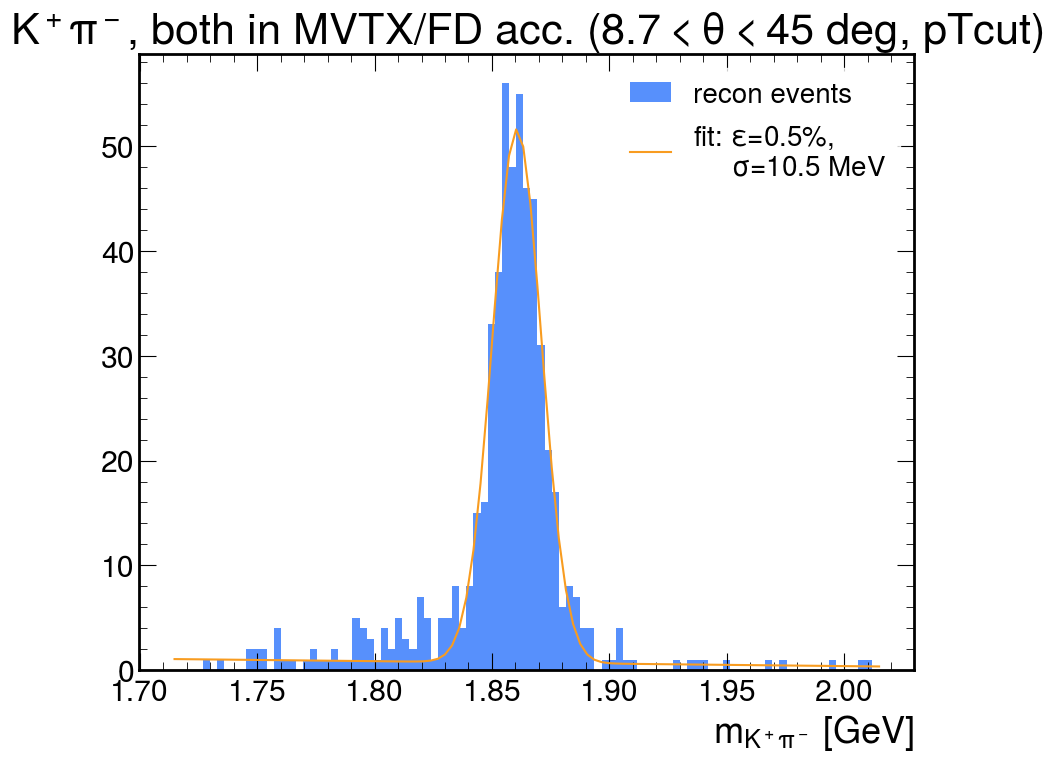

In [18]:
for arrays, usePID in (arrays_nopid, False), (arrays_withpid, True):
    selections=[]
    selections.append([(arrays['topo']==0), "$K^+\\pi^-$, no MVTX requirement"])
    deg=np.pi/180
    # selections.append([(arrays['topo']==0)&(arrays['K_th']>8.7*deg)&(arrays['K_th']<90*deg), "$K^+$ in MVTX"])
    # selections.append([(arrays['topo']==0)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<90*deg), "$\\pi^-$ in MVTX"])
    selections.append([(arrays['topo']==0)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<90*deg)&\
                       (arrays['K_th']>8.7*deg)&(arrays['K_th']<90*deg), "$K^+\\pi^-$, both in MVTX acc. ($8.7<\\theta<90$ deg)"])
    selections.append([(arrays['topo']==0)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<45*deg)&\
                       (arrays['K_th']>8.7*deg)&(arrays['K_th']<45*deg), "$K^+\\pi^-$, both in MVTX/FD acc. ($8.7<\\theta<45$ deg)"])
    selections.append([(arrays['topo']==0)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<45*deg)&\
                       (arrays['K_th']>8.7*deg)&(arrays['K_th']<45*deg)\
                       &(np.sin(arrays['K_th'])*arrays['K_p']>min_pT)\
                       &(np.sin(arrays['pi_th'])*arrays['pi_p']>min_pT), "$K^+\\pi^-$, both in MVTX/FD acc. ($8.7<\\theta<45$ deg, pTcut)"])

    for selection, title in selections:
        y, x, _ = plt.hist(arrays['invmass'][selection],bins=np.linspace(m_D0bar-.15,m_D0bar+.15, 100),
                          label='recon events')
        bc=(x[1:]+x[:-1])/2
        p0=(100, m_D0bar, 0.03, 0,0)
        fnc=gauss_plus_poly
        dy=np.sqrt(y)+(y==0)
        coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
        dx=x[1]-x[0]
        label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
        xx=np.linspace(x[0],x[-1],100)
        plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
        plt.xlabel("$m_{K^+\pi^-}$ [GeV]")
        plt.legend(fontsize=20)
        plt.title(title)
        plt.show()

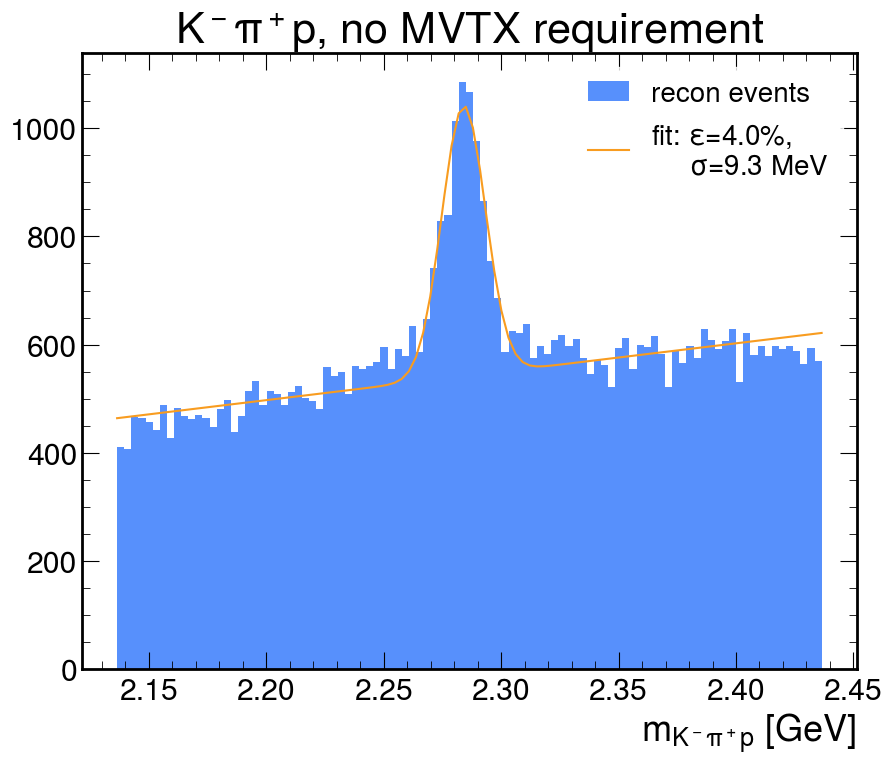

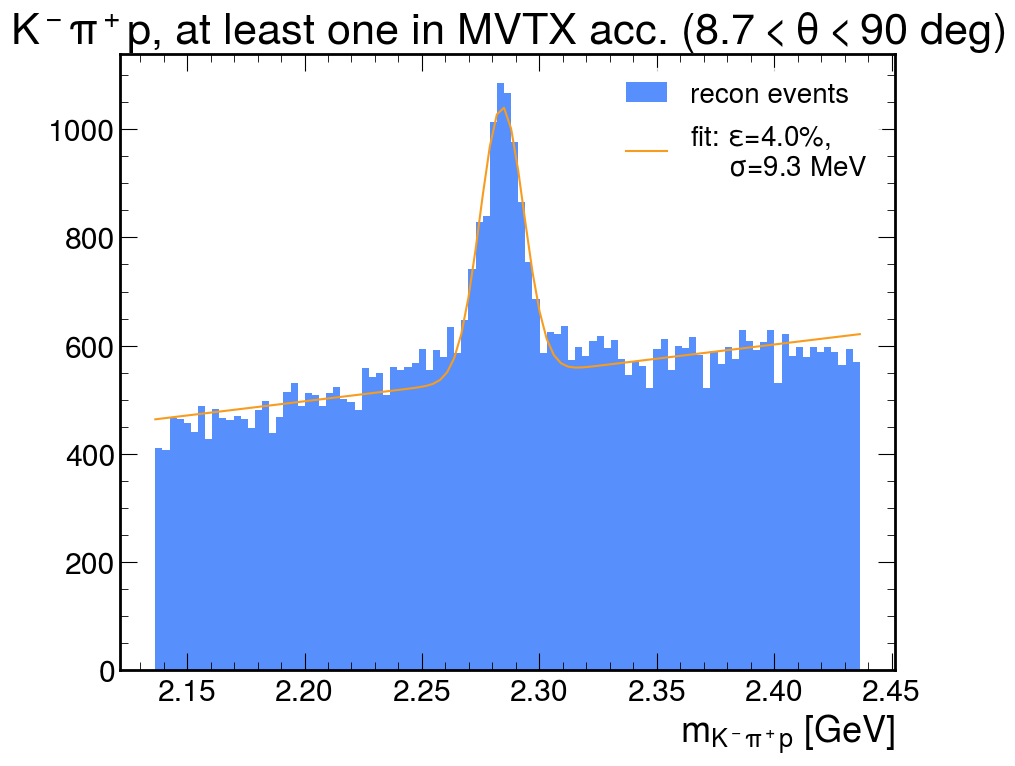

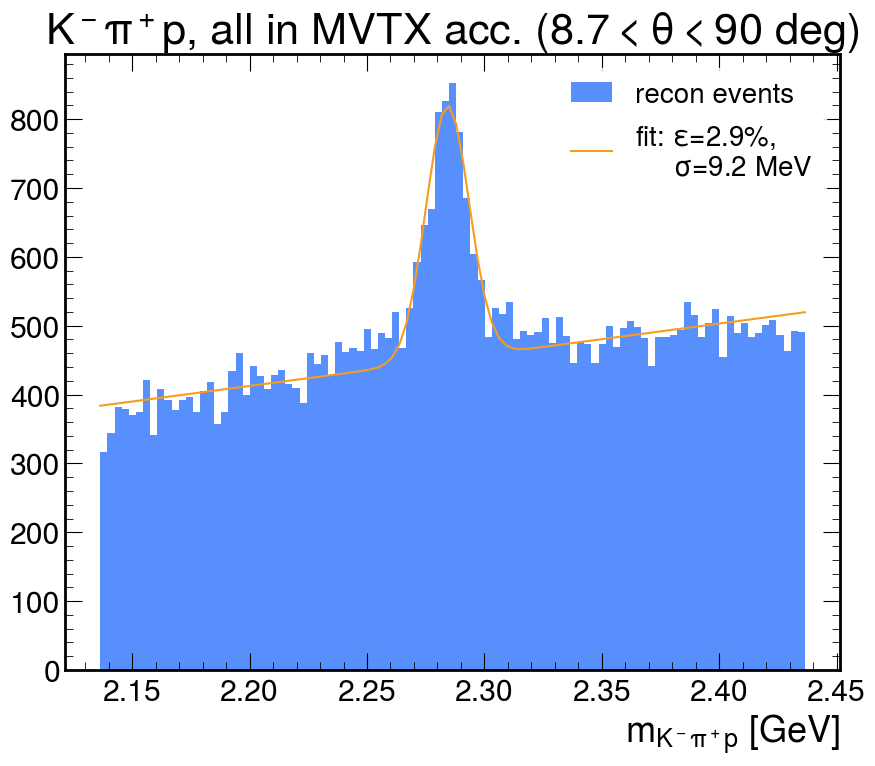

In [15]:
for arrays in arrays_nopid,:
    selections=[]
    selections.append([(arrays['topo']==2), "$K^-\\pi^+p$, no MVTX requirement"])
    deg=np.pi/180
    # selections.append([(arrays['topo']==0)&(arrays['K_th']>8.7*deg)&(arrays['K_th']<90*deg), "$K^+$ in MVTX"])
    # selections.append([(arrays['topo']==0)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<90*deg), "$\\pi^-$ in MVTX"])

    #k,pi,p=

    selections.append([(arrays['topo']==2)&(((arrays['pi_th']>8.7*deg)&(arrays['pi_th']<90*deg))|\
                       ((arrays['K_th']>8.7*deg)&(arrays['K_th']<90*deg))|\
                       ((arrays['prot_th']>8.7*deg)&(arrays['prot_th']<90*deg))), "$K^-\\pi^+p$, at least one in MVTX acc. ($8.7<\\theta<90$ deg)"])
    selections.append([(arrays['topo']==2)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<90*deg)&\
                       (arrays['K_th']>8.7*deg)&(arrays['K_th']<90*deg)&\
                       (arrays['prot_th']>8.7*deg)&(arrays['prot_th']<90*deg), "$K^-\\pi^+p$, all in MVTX acc. ($8.7<\\theta<90$ deg)"])


    for selection, title in selections:
        y, x, _=plt.hist(arrays['invmass'][selection],bins=np.linspace(m_lcp-.15,m_lcp+.15, 100),
                        label='recon events')
        bc=(x[1:]+x[:-1])/2
        p0=(100, m_lcp, 0.03, 0,0)
        fnc=gauss_plus_poly
        dy=np.sqrt(y)+(y==0)
        coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
        dx=x[1]-x[0]
        label=f"fit: $\\epsilon$={100*coeff[0]/dx/Ngen:.1f}%,\n     $\\sigma$={coeff[2]*1000:.1f} MeV"
        xx=np.linspace(x[0],x[-1],100)
        plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
        plt.xlabel("$m_{K^-\pi^+p}$ [GeV]")
        plt.legend(fontsize=20)
        plt.title(title)
        plt.show()


398764


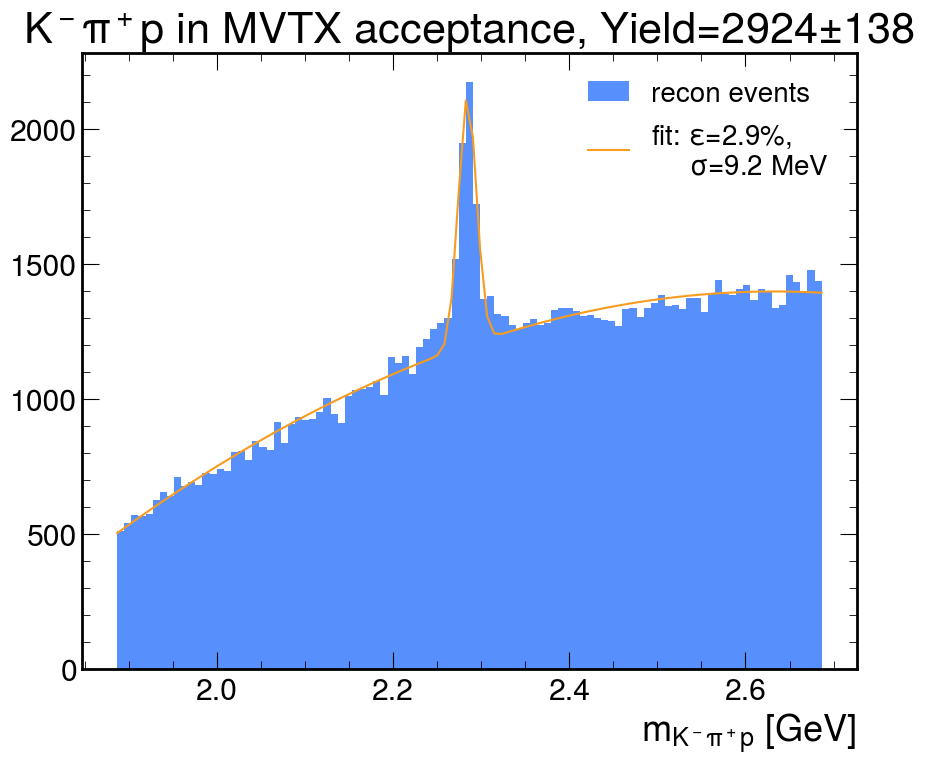

7090.438615822863


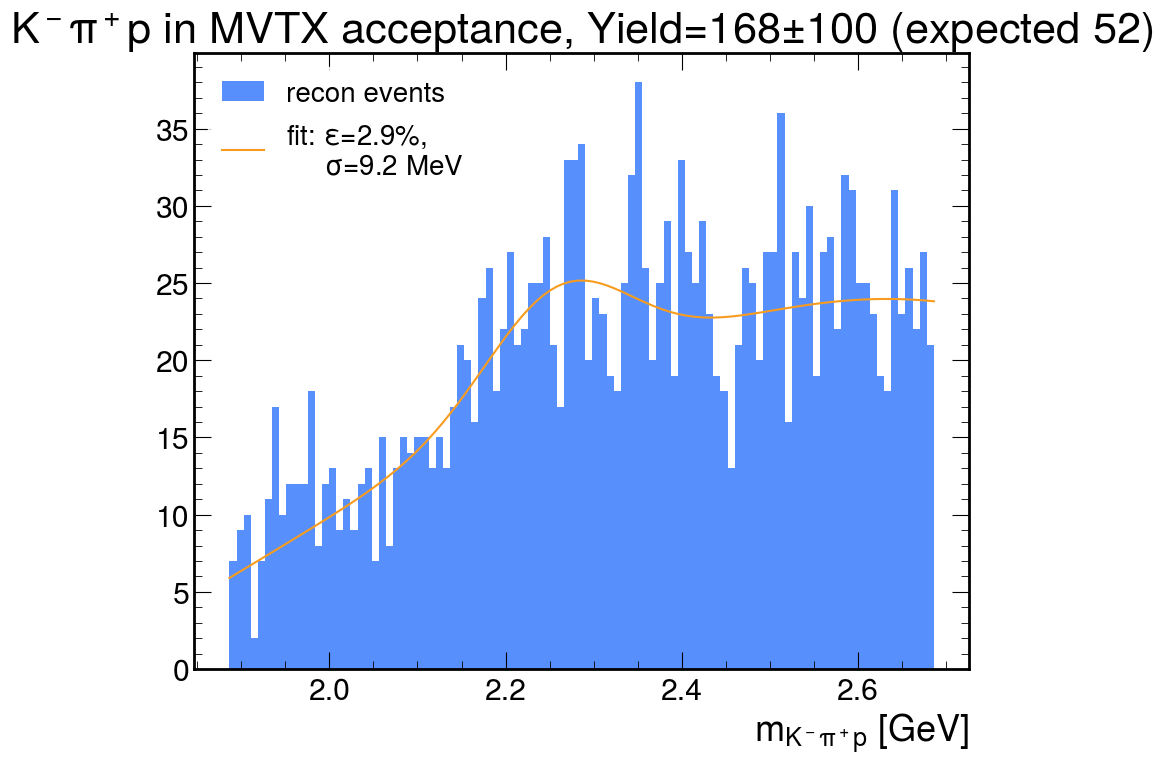

28361.75446329145


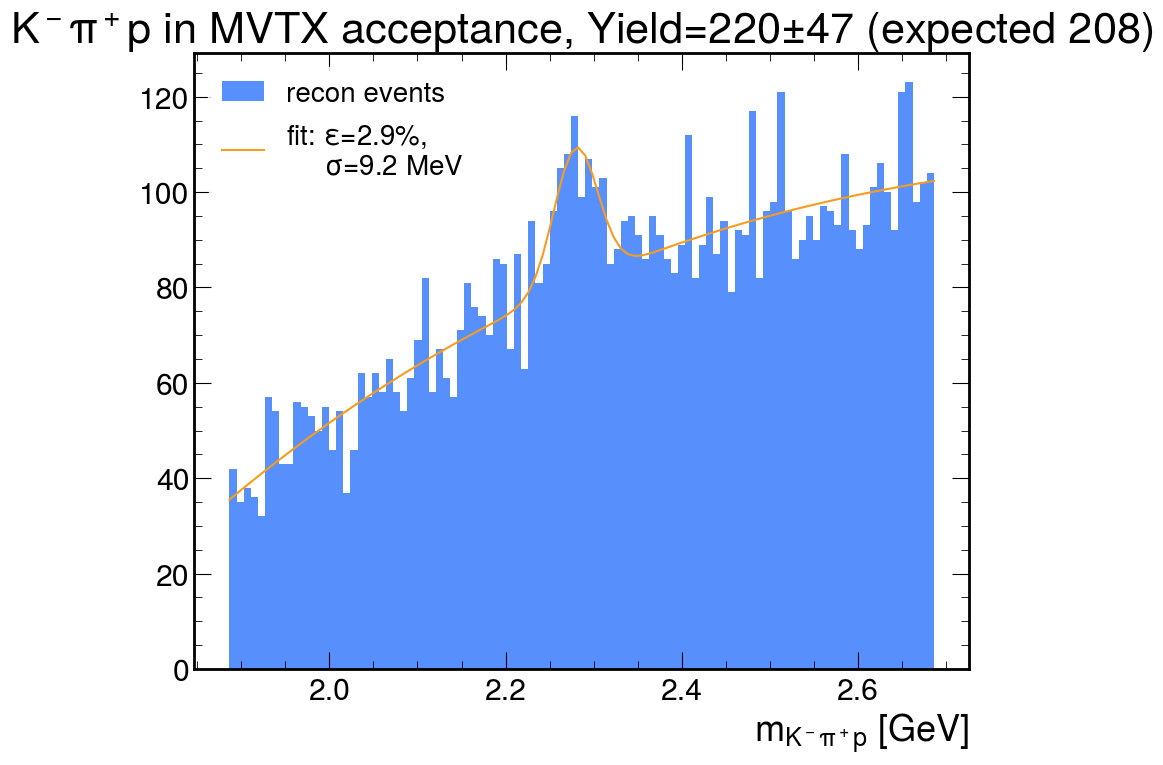

In [16]:
#now emulate having low statistics and smear the resolution by factor of 2

for iteration in 0, 1,2:
    
    arrays =arrays_nopid
    selections=[]
    selections.append([(arrays['topo']==2), "$K^-\\pi^+p$, no MVTX requirement"])
    deg=np.pi/180
    
    selection=(arrays['topo']==2)&(arrays['pi_th']>8.7*deg)&(arrays['pi_th']<90*deg)&\
                       (arrays['K_th']>8.7*deg)&(arrays['K_th']<90*deg)&\
                       (arrays['prot_th']>8.7*deg)&(arrays['prot_th']<90*deg)
    
    if iteration == 1:
        Nexp=52
    if iteration == 2:
        Nexp=208
    maxevt=len(arrays) if iteration ==0 else len(arrays)*Nexp/N0
    print(maxevt)
    
    vals=arrays['invmass'][0:maxevt][selection[0:maxevt]]
    
    #smear by factor of 2
    if iteration !=0:
        vals=np.array(list(vals))
        import random
        r=random.Random()
        f=2
        smear=sigma0*np.sqrt(f**2-1)
        vals=vals+[r.gauss(0,smear) for i in range(len(vals))]
    y, x, _=plt.hist(vals,bins=np.linspace(m_lcp-.4,m_lcp+.4, 100),
                    label='recon events')
    bc=(x[1:]+x[:-1])/2
    p0=(100, m_lcp, 0.03, 0,0,0,0)
    fnc=gauss_plus_poly
    dy=np.sqrt(y)+(y==0)
    coeff, var_matrix = curve_fit(fnc, bc, y, p0=p0,sigma=dy)
    dx=x[1]-x[0]
    N=coeff[0]/dx
    if iteration==0:
        N0=N
        sigma0=coeff[2]
    dN=np.sqrt(var_matrix[0][0])/dx

    

    xx=np.linspace(x[0],x[-1],100)
    plt.plot(xx, gauss_plus_poly(xx,*coeff), label=label)
    plt.xlabel("$m_{K^-\pi^+p}$ [GeV]")
    plt.legend(fontsize=20)
    plt.title(f"$K^-\\pi^+p$ in MVTX acceptance, Yield={N:.0f}$\\pm${dN:.0f}"+(f" (expected {Nexp})" if iteration!=0 else ""))
    plt.show()


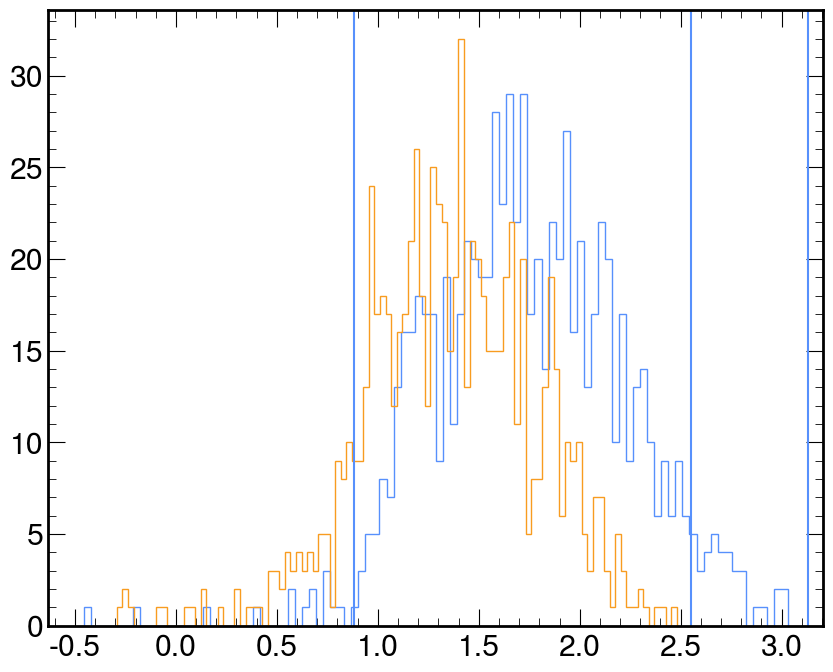

In [16]:
selection=arrays['topo']==0

def Y(th):
    return -np.log(np.tan(th/2))
plt.hist(Y(arrays[selection]['K_th']), bins=100, histtype='step')
plt.hist(Y(arrays[selection]['pi_th']), bins=100, histtype='step')

plt.axvline(Y(45/180*np.pi))
plt.axvline(Y(5/180*np.pi))
plt.axvline(Y(8.9/180*np.pi))

2184

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        2.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 3.000e+00, 4.000e+00,
        2.000e+00, 1.000e+00, 2.000e+00, 4.000e+00, 3.000e+00, 3.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 5.000e+00, 4.000e+00, 4.000e+00,
        1.000e+00, 3.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 4.000e+00, 1.000e+00,
        1.000e+00, 3.000e+00, 4.000e+00, 6.000e+00, 6.000e+00, 1.000e+01,
        1.400e+01, 1.800e+01, 3.300e+0

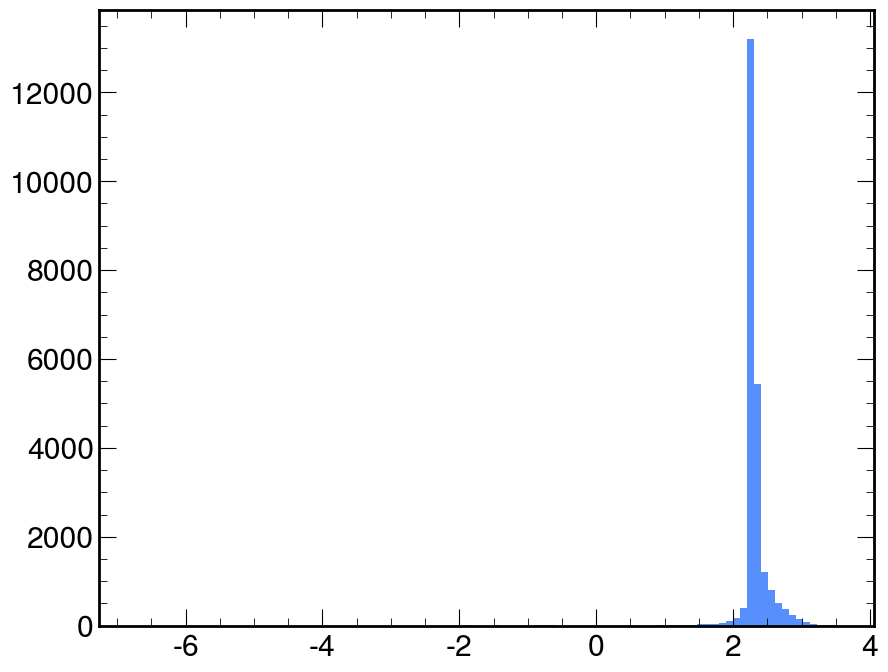

In [66]:
plt.hist(arrays_nopid.missmass, bins=100)

(array([  1.,   1.,   0.,   0.,   1.,   2.,   2.,   5.,  15.,  25.,  25.,
         47.,  66.,  81., 113., 126., 139., 159., 180., 180., 208., 244.,
        240., 273., 260., 254., 299., 275., 323., 304., 293., 304., 327.,
        283., 275., 307., 306., 298., 253., 283., 271., 271., 238., 244.,
        254., 237., 218., 207., 217., 209., 185., 199., 160., 160., 146.,
        124., 125., 119., 110.,  96.,  79.,  81.,  64.,  87.,  66.,  50.,
         29.,  29.,  25.,  12.,  20.,  13.,   3.,   5.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.42515352, 0.43681832, 0.44848312, 0.46014792, 0.47181272,
        0.48347752, 0.49514232, 0.50680712, 0.51847192, 0.53013672,
        0.54180152, 0.55346632, 0.56513112, 0.57679593, 0.58846073,
        0.60012553, 0.61179033, 0.62345513, 0.63511993, 0.64678473,
        0.65844953, 0.67011433, 0.68177913, 0.

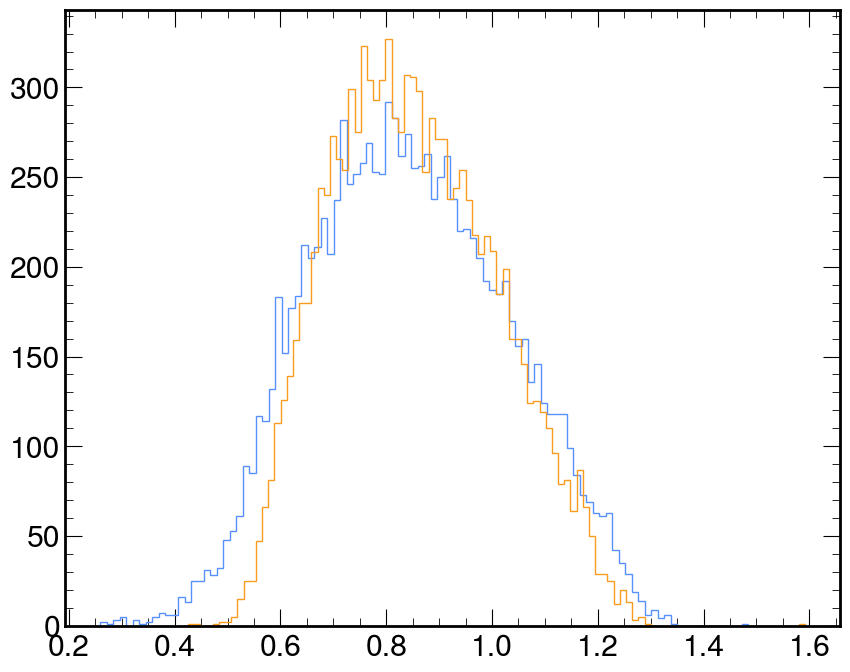

In [91]:
selection=(arrays['mvtx_status']==63)&(arrays['invmass']>1.8)&(arrays['invmass']<1.9)

plt.hist(np.hypot(arrays[selection]['K_px'], arrays[selection]['K_py']), bins=100, histtype='step')
plt.hist(np.hypot(arrays[selection]['pi_px'], arrays[selection]['pi_py']), bins=100, histtype='step')


(array([2.338e+03, 1.058e+03, 4.420e+02, 1.830e+02, 1.040e+02, 4.100e+01,
        1.700e+01, 1.100e+01, 6.000e+00, 3.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.690e+02, 2.238e+03, 1.017e+03,
        4.110e+02, 1.970e+02, 9.200e+01, 3.600e+01, 2.200e+01, 9.000e+00,
        2.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 3.300e+02, 2.155e+03, 1.016e+03, 4.300e+02, 2.110e+02,
        8.500e+01, 5.100e+01, 1.800e+01, 1.100e+01, 3.000e+00, 4.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 5.350e+02,
        2.181e+03, 9.430e+02, 4.120e+02, 2.220e+02, 8.100e+01, 4.700e+01,
        1.500e+01, 1.100e+01, 2.000e+00, 3.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

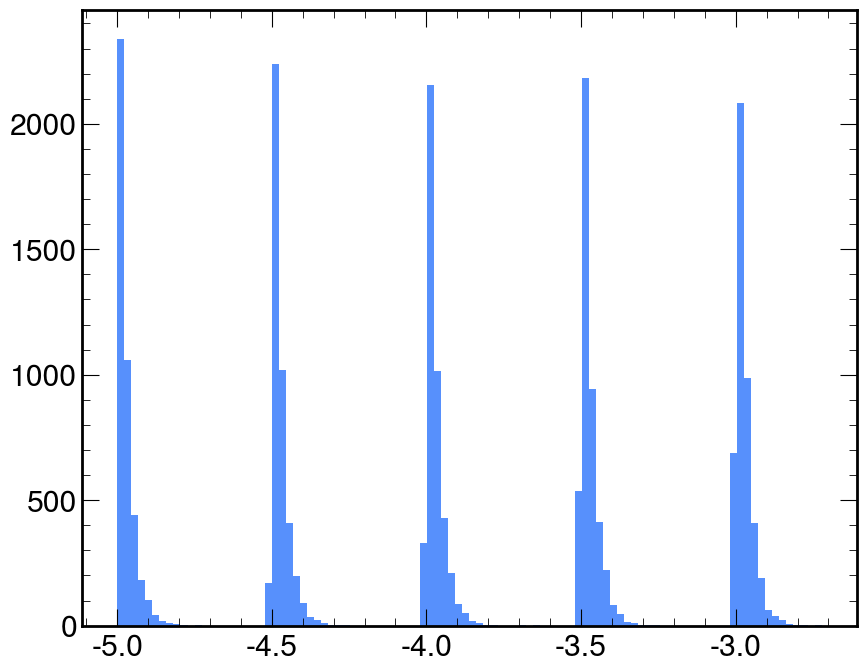

In [92]:
plt.hist(df.vtx_z_mc, bins=100)

(-60.0, -20.0)

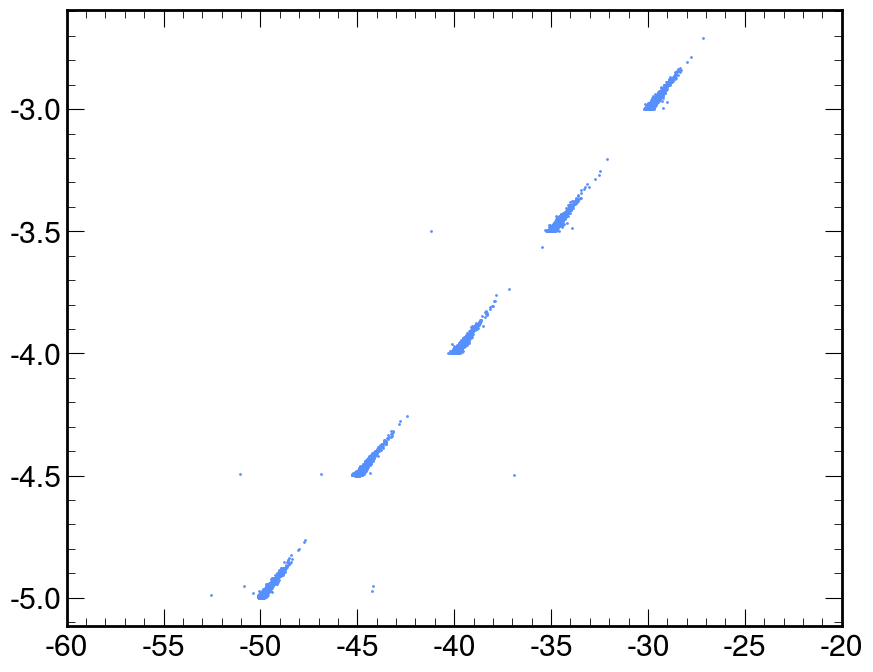

In [218]:
dfq=df.query("abs(doca)<.1")
plt.scatter(dfq.vtx_z,dfq.vtx_z_mc, s=1)
plt.xlim(-60, -20)

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   5.,  41.,  85., 193., 239., 296., 385., 385., 389.,
        360., 400., 400., 402., 398., 405., 369., 381., 363., 348., 328.,
        295., 306., 245., 263., 231., 222., 202., 213., 187., 168., 152.,
        134., 116., 119., 102.,  89.,  75.,  60.,  51.,  42.,  34.,  46.,
         55.,  51.,  50.,  46.,  43.,  32.,  29.,  22.,  24.,  20.,   9.,
         12.,  17.,   7.,  12.,   6.,   7.,   9.,   6.,   6.,   3.,   4.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([-50. , -46.5, -43. , -39.5, -36. , -32.5, -29. , -25.5, -22. ,
        -18.5, -15. , -11.5,  -8. ,  -4.5,  -1. ,   2.5,   6. ,   9.5,
         13. ,  16.5,  20. ,  23.5,  27. ,  30.5,  34. ,  37.5,  41. ,
         44.5,  48. ,  51.5,  55. ,  58.5,  62. ,  65.5,  69. ,  72.5,
         76. ,  79.5,  83. ,  86.5

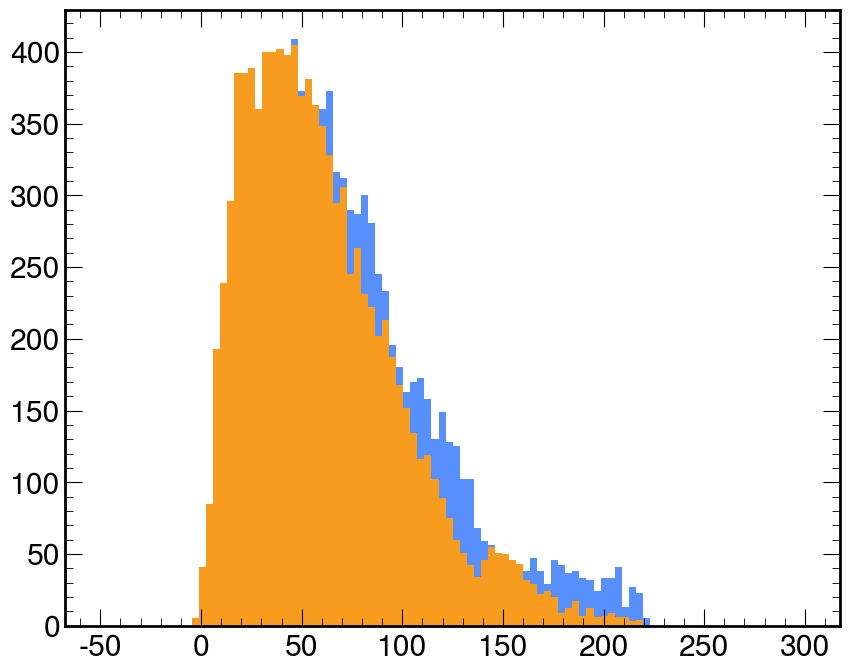

In [390]:
q='mvtx_status==63 and K_p>0.5 and pi_p>0.5 and invmass>1.83 and invmass<1.9 and abs(doca)<.2'
plt.hist(df.query(q)['K_MVTX_z2'], bins=100, range=(-50, 300))
plt.hist(df.query(q)['pi_MVTX_z2'], bins=100, range=(-50, 300))

(array([  0.,   0.,   0.,   1.,   0.,   2.,   2.,   2.,   9.,   7.,   3.,
         13.,  17.,  11.,  19.,  26.,  22.,  36.,  39.,  48.,  42.,  60.,
         61.,  70.,  53.,  81.,  97.,  67., 105.,  97., 120., 129., 127.,
        142., 157., 190., 228., 315., 376., 373., 445., 475., 550., 579.,
        632., 658., 663., 723., 717., 717., 769., 738., 719., 708., 750.,
        699., 676., 684., 639., 587., 611., 576., 511., 531., 431., 449.,
        424., 384., 365., 342., 287., 279., 243., 211., 203., 170., 158.,
        118.,  95.,  90.,  64.,  42.,  22.,  12.,   8.,   4.,   6.,   0.,
          4.,   3.,   2.,   0.,   2.,   4.,   2.,   4.,   2.,   4.,   0.,
          3.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
        110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160.,
        165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215.,
        220., 225., 23

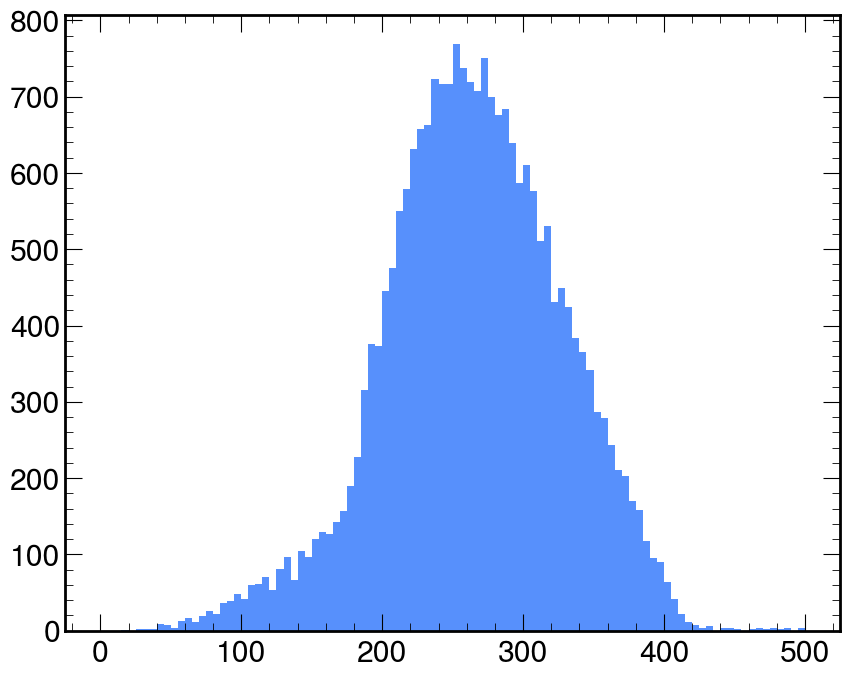

In [551]:
plt.hist((df.pi_pz+df.K_pz)*120/1.864, range=(0, 500), bins=100)